<a href="https://colab.research.google.com/github/anittajoshy2001-dot/decision-tree-penguins-tutorial/blob/main/notebooks/Memory_Malware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import warnings as warn
warn.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split as data_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
mal_mem = pd.read_csv("hf://datasets/bvk/CIC-MalMem-2022/MalMem2022.csv")
mal_mem

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58591,40,16,9.825000,0,208.075000,1556,38.900000,8323,208.075000,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58592,39,15,9.974359,0,210.358974,1521,39.000000,8204,210.358974,0,...,24,116,0,120,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58593,37,15,10.054054,0,214.702703,1445,39.054054,7944,214.702703,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58594,37,15,10.108108,0,214.675676,1445,39.054054,7943,214.675676,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...


In [ ]:
print("Shape of the dataset:", mal_mem.shape)
print("Dataset columns:", mal_mem.columns)

Shape of the dataset: (58596, 58)
Dataset columns: Index(['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads',
       'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls',
       'dlllist.avg_dlls_per_proc', 'handles.nhandles',
       'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile',
       'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread',
       'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer',
       'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load',
       'ldrmodules.not_in_init', 'ldrmodules.not_in_mem',
       'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg',
       'ldrmodules.not_in_mem_avg', 'malfind.ninjections',
       'malfind.commitCharge', 'malfind.protection',
       'malfind.uniqueInjections', 'psxview.not_in_pslist',
       'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool',
       'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles',
       'psxview.not_in_session', 

In [ ]:
mal_mem['Class'].value_counts()

,count
Class,
Benign,29298
Malware,29298


In [ ]:
mal_mem.to_csv('/MalMem2022.csv', index=False)

In [ ]:
mal_mem.head(10)

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign
5,40,12,13.800000,0,306.950000,2082,52.050000,12278,306.950000,0,...,27,118,0,123,88,0,8,Benign,Benign,Benign
6,43,13,13.813953,0,305.023256,2169,50.441860,13116,305.023256,0,...,27,118,0,123,88,0,8,Benign,Benign,Benign
7,42,16,11.452381,0,281.404762,2067,49.214286,11819,281.404762,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign
8,42,16,11.452381,0,281.261905,2067,49.214286,11813,281.261905,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign
9,40,12,13.875000,0,308.000000,2082,52.050000,12320,308.000000,0,...,27,118,0,123,88,0,8,Benign,Benign,Benign


In [ ]:
mal_mem.tail(10)

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
58586,39,15,11.384615,0,220.128205,1560,40.000000,8585,220.128205,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58587,35,14,10.228571,0,213.885714,1377,39.342857,7486,213.885714,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58588,41,16,10.317073,0,211.170732,1614,39.365854,8658,211.170732,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58589,41,16,10.121951,0,209.707317,1605,39.146341,8598,209.707317,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58590,41,16,9.707317,0,207.609756,1605,39.146341,8512,207.609756,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58591,40,16,9.825000,0,208.075000,1556,38.900000,8323,208.075000,0,...,24,116,0,121,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58592,39,15,9.974359,0,210.358974,1521,39.000000,8204,210.358974,0,...,24,116,0,120,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58593,37,15,10.054054,0,214.702703,1445,39.054054,7944,214.702703,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58594,37,15,10.108108,0,214.675676,1445,39.054054,7943,214.675676,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58595,37,15,10.108108,0,214.351351,1445,39.054054,7931,214.351351,0,...,24,116,0,118,87,0,8,Malware,Trojan-Zeus,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...


In [ ]:
mal_mem['Category'].value_counts()

,count
Category,
Benign,29298
Spyware-Transponder,2410
Spyware-Gator,2200
Ransomware-Shade,2128
Spyware-CWS,2000
Trojan-Scar,2000
Spyware-180solutions,2000
Ransomware-Ako,2000
Trojan-Refroso,2000


In [ ]:
mal_mem['Category'] = mal_mem['Category'].str.split('-').str[0]
mal_mem['Category'].unique()

array(['Benign', 'Ransomware', 'Spyware', 'Trojan'], dtype=object)

In [ ]:
mal_mem['Category'].value_counts()

,count
Category,
Benign,29298
Spyware,10020
Ransomware,9791
Trojan,9487


In [ ]:
mal_mem.tail(5)

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
58591,40,16,9.825000,0,208.075000,1556,38.900000,8323,208.075000,0,...,24,116,0,121,87,0,8,Malware,Trojan,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58592,39,15,9.974359,0,210.358974,1521,39.000000,8204,210.358974,0,...,24,116,0,120,87,0,8,Malware,Trojan,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58593,37,15,10.054054,0,214.702703,1445,39.054054,7944,214.702703,0,...,24,116,0,118,87,0,8,Malware,Trojan,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58594,37,15,10.108108,0,214.675676,1445,39.054054,7943,214.675676,0,...,24,116,0,118,87,0,8,Malware,Trojan,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...
58595,37,15,10.108108,0,214.351351,1445,39.054054,7931,214.351351,0,...,24,116,0,118,87,0,8,Malware,Trojan,Trojan-Zeus-4b7dea7d5eb079c84f3f62fe4681732e55...


In [ ]:
#dropping file name since its only an identifier
mal_mem = mal_mem.drop("Filename", axis=1)

In [ ]:
# Find columns with only 1 unique value
cols_to_drop = [col for col in mal_mem.columns if mal_mem[col].nunique() == 1]
print("Columns with 1 unique value:", cols_to_drop)

Columns with 1 unique value: ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']


In [ ]:
mal_mem = mal_mem.drop(columns=cols_to_drop)
mal_mem.shape

(58596, 54)

In [ ]:
mal_mem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 54 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   pslist.nproc                            58596 non-null  int64  
 1   pslist.nppid                            58596 non-null  int64  
 2   pslist.avg_threads                      58596 non-null  float64
 3   pslist.avg_handlers                     58596 non-null  float64
 4   dlllist.ndlls                           58596 non-null  int64  
 5   dlllist.avg_dlls_per_proc               58596 non-null  float64
 6   handles.nhandles                        58596 non-null  int64  
 7   handles.avg_handles_per_proc            58596 non-null  float64
 8   handles.nfile                           58596 non-null  int64  
 9   handles.nevent                          58596 non-null  int64  
 10  handles.ndesktop                        58596 non-null  in

**Checking for Null values and Duplicate data**

In [ ]:
print(f"Nulls: {mal_mem.isnull().sum().sum()}, Duplicates: {mal_mem.duplicated().sum()}")

Nulls: 0, Duplicates: 559


In [ ]:
mal_mem = mal_mem.drop_duplicates(); print(mal_mem.shape) #dropping duplicates and shape after dropping duplicates

(58037, 54)


**Visualising the Distribution of Classes and Categories**

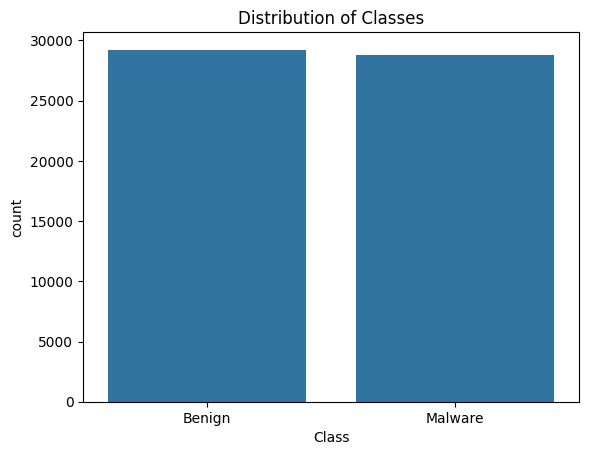

In [ ]:
sns.countplot(x='Class', data=mal_mem)
plt.title('Distribution of Classes')
plt.show()

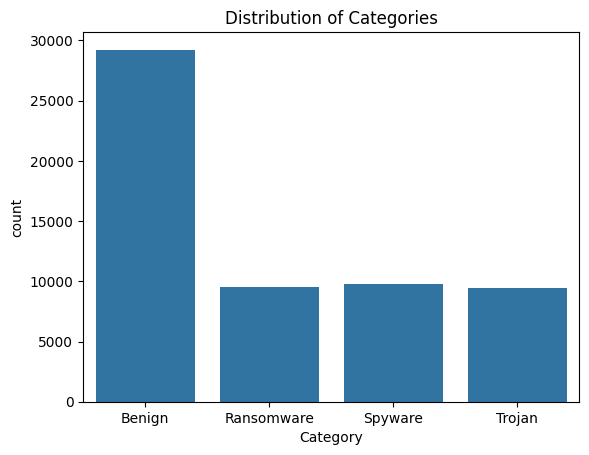

In [ ]:
sns.countplot(x='Category', data=mal_mem)
plt.title('Distribution of Categories')
plt.show()

**Encoding the categorical features**

In [ ]:
# Encode 'Class' and 'Category'
mal_mem['Class'] = LabelEncoder().fit_transform(mal_mem['Class'])
mal_mem['Category'] = LabelEncoder().fit_transform(mal_mem['Category'])
print(mal_mem.dtypes)

pslist.nproc                                int64
pslist.nppid                                int64
pslist.avg_threads                        float64
pslist.avg_handlers                       float64
dlllist.ndlls                               int64
dlllist.avg_dlls_per_proc                 float64
handles.nhandles                            int64
handles.avg_handles_per_proc              float64
handles.nfile                               int64
handles.nevent                              int64
handles.ndesktop                            int64
handles.nkey                                int64
handles.nthread                             int64
handles.ndirectory                          int64
handles.nsemaphore                          int64
handles.ntimer                              int64
handles.nsection                            int64
handles.nmutant                             int64
ldrmodules.not_in_load                      int64
ldrmodules.not_in_init                      int64


**Heat Map Analysis**

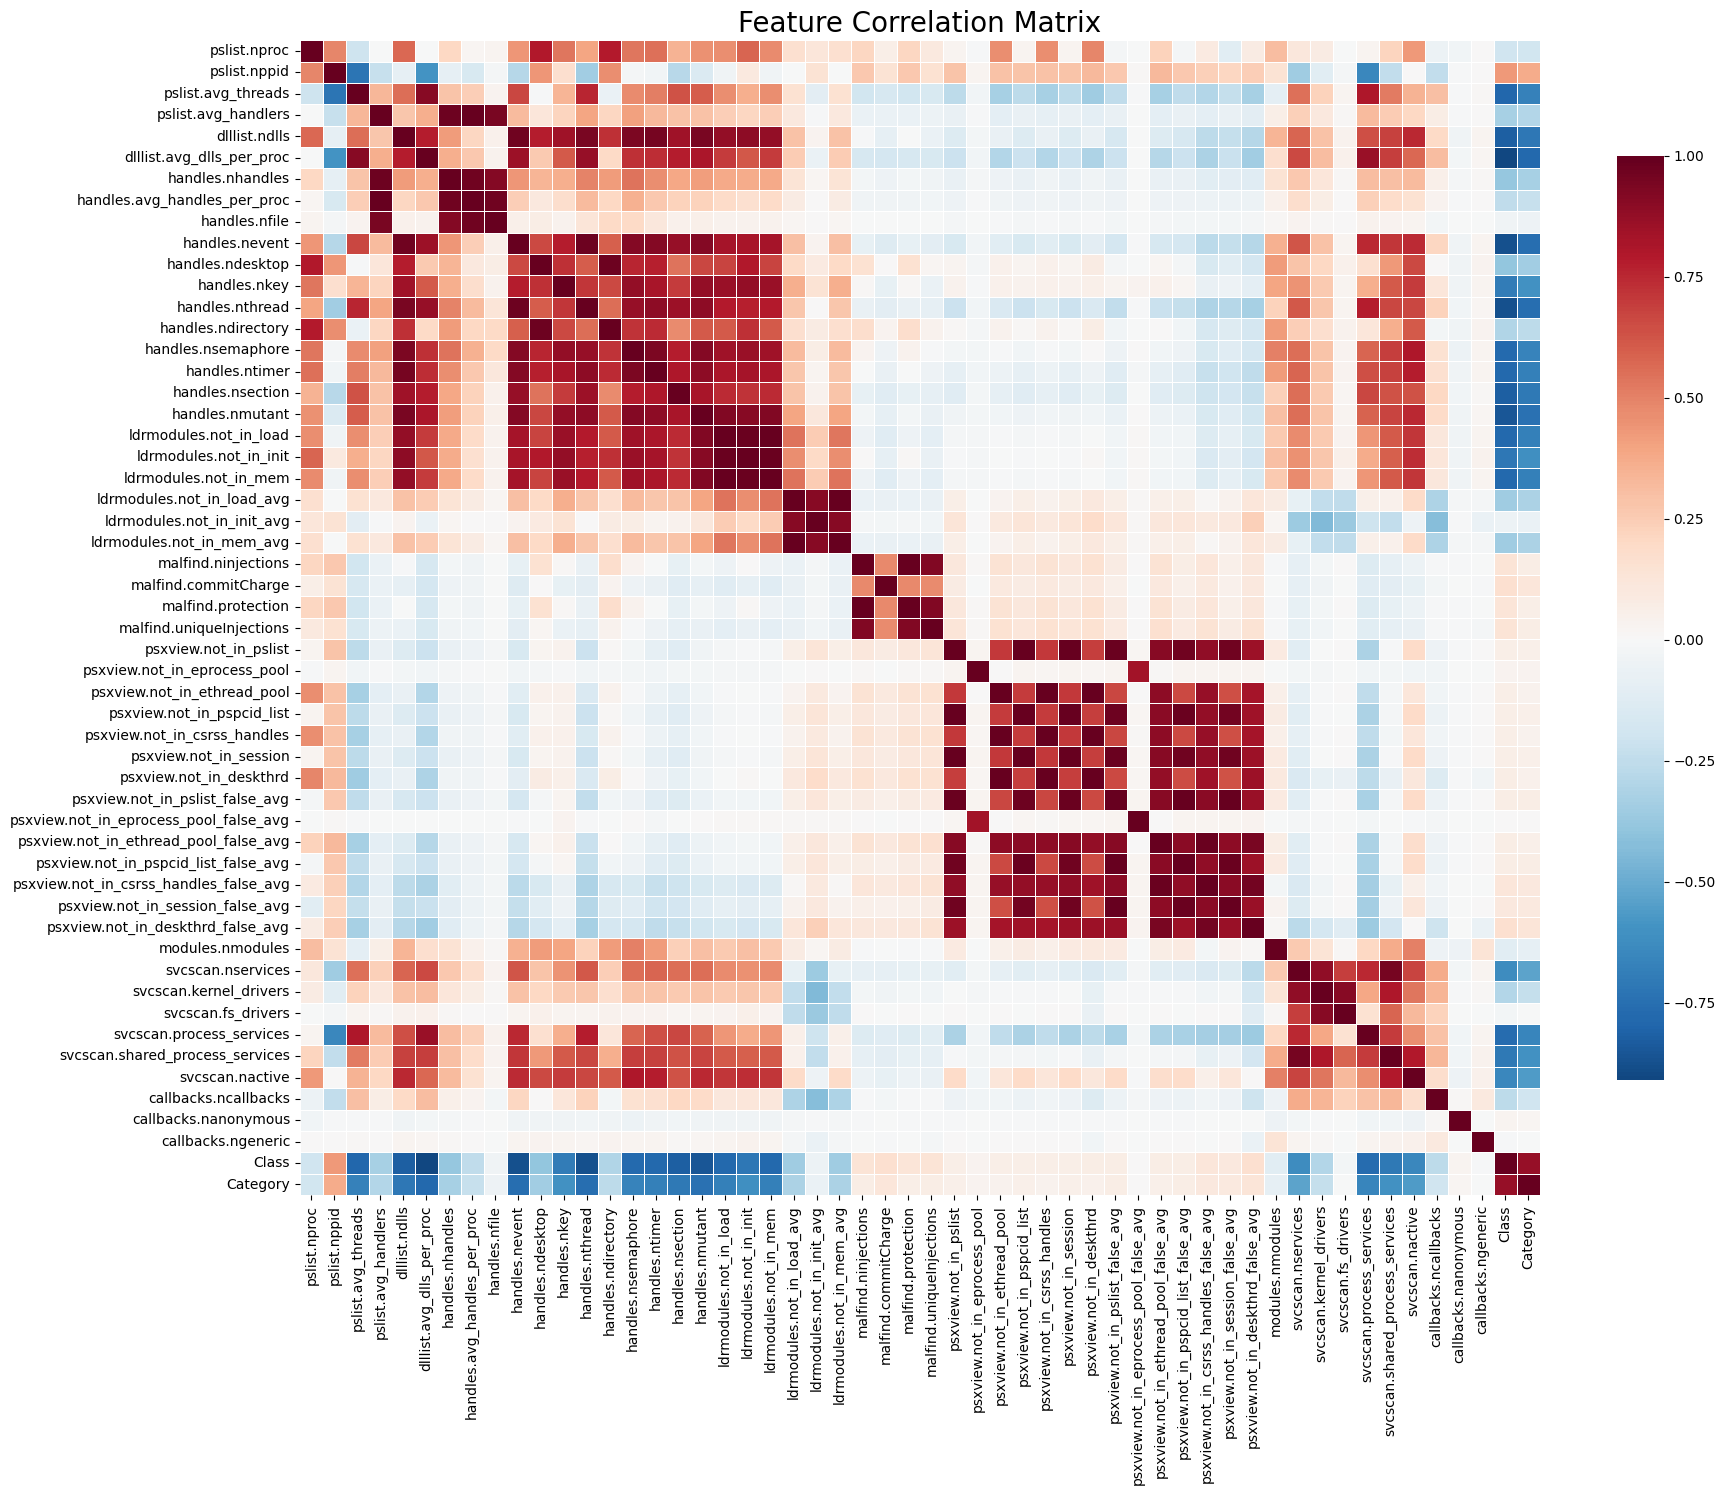

In [ ]:
import numpy as np

corr_matrix = mal_mem.corr()

plt.figure(figsize=(20, 15))

sns.heatmap(corr_matrix,
            cmap='RdBu_r',
            center=0,
            annot=False,   # keep False to avoid crowding
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix', fontsize=20)
plt.show()

**KDE Plot - Memory Injection Distribution**

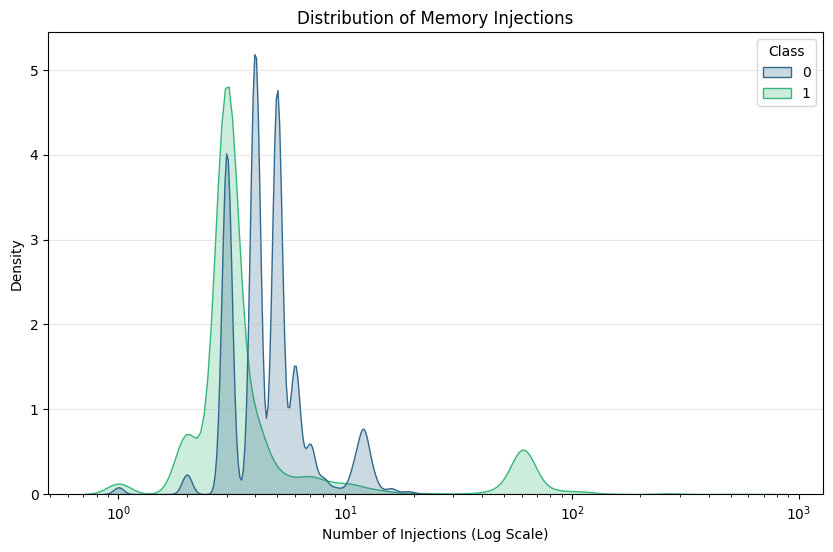

In [ ]:
plt.figure(figsize=(10, 6))
# Using log_scale to handle the extreme outliers (0 to 600 range)
sns.kdeplot(data=mal_mem, x='malfind.ninjections', hue='Class', fill=True,
            log_scale=True, palette='viridis', common_norm=False)

plt.title('Distribution of Memory Injections')
plt.xlabel('Number of Injections (Log Scale)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
plt.show()

Grouped Bar Chart for Hidden Behaviors

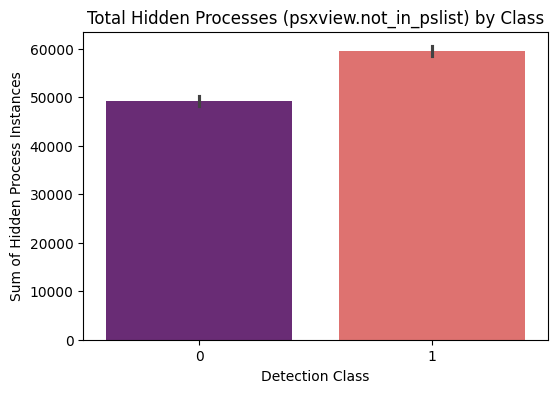

In [ ]:
# Aggregating the 'not_in_pslist' count to see visibility discrepancies
plt.figure(figsize=(6, 4))
sns.barplot(data=mal_mem, x='Class', y='psxview.not_in_pslist', estimator=sum, palette='magma')
plt.title('Total Hidden Processes (psxview.not_in_pslist) by Class')
plt.ylabel('Sum of Hidden Process Instances')
plt.xlabel('Detection Class')
plt.show()

In [ ]:
mal_mem['Category'].value_counts()

,count
Category,
0,29231
2,9803
1,9523
3,9480


In [ ]:
mal_mem['Class'].value_counts()

,count
Class,
0,29231
1,28806


In [ ]:
mal_mem.to_csv('/Memory_Malware.csv', index=False)

# 1. Binary Malware Detection using PCA and Deep Learning

This is a binary classification approach for detecting malware from memory data.  
The CICMalMem dataset is used and dimensionality reduction is performed using **Principal Component Analysis (PCA)**.

Three deep learning models are evaluated:

- LSTM
- RNN
- CNN

The workflow includes data preprocessing, dimensionality reduction, model training, and evaluation.

## Dataset Loading

The CICMalMem dataset is loaded into a pandas dataframe.  
The dataset contains memory-based features extracted from running processes.

In [ ]:
mal_mem = pd.read_csv("/content/drive/MyDrive/Data/Memory_Malware.csv")

mal_mem.shape

(58037, 54)

## Target Distribution

The `Class` column represents the binary target variable:

- 0 → Benign
- 1 → Malware

Checking class balance is important to ensure the dataset does not introduce bias during training.

In [ ]:
mal_mem['Class'].value_counts()

,count
Class,
0,29231
1,28806


data is balanced

# *Data splitting*

In [ ]:
X_feat = mal_mem.drop(columns=['Class'])
y_output = mal_mem['Class']

Splitting: 70% for training, 15% for validation and 15% for testing

In [ ]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = data_split(X_feat, y_output, test_size=0.30, stratify=y_output, random_state=42)

# Second split: Split temp into 50% validation and 50% test → each 15% of total
X_val, X_test, y_val, y_test = data_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Training data: {X_train.shape}")
print(f"Validation data: {X_val.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (40625, 53)
Validation data: (8706, 53)
Testing data: (8706, 53)


In [ ]:
print("\nPreview of first five rows of Training data after splitting")
X_train[:5]


Preview of first five rows of Training data after splitting


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,handles.nevent,...,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Category
6709,43,12,12.196651,280.742138,2170,50.465116,12071,280.742138,1064,4245,...,395,222,26,27,118,122,88,0,8,0
27682,41,13,13.110555,294.331026,2026,49.420812,12067,294.331026,1088,4435,...,395,222,26,27,118,123,88,0,8,0
49160,42,16,10.166667,208.500000,1631,38.833333,8757,208.500000,664,3029,...,389,221,26,24,116,122,86,0,8,3
776,50,18,11.940000,267.060000,2321,47.367347,13353,267.060000,1097,4639,...,392,222,26,24,118,126,87,0,8,0
41896,44,17,9.545455,200.636364,1692,38.454545,8828,200.636364,672,3073,...,389,221,26,24,116,122,86,0,8,2


## Data Scaling

Standardization is applied using **StandardScaler** to normalize feature values.
This ensures that features with large numeric ranges do not dominate the learning process.

In [ ]:
std_scale = StandardScaler()
X_train_std = std_scale.fit_transform(X_train)
X_val_std = std_scale.transform(X_val)
X_test_std = std_scale.transform(X_test)

print("\nPreview of first three rows of Training data after scaling using standard scaler")
X_train_std[:3]


Preview of first three rows of Training data after scaling using standard scaler


array([[ 0.27175813, -1.01639901,  0.53249564,  0.25018469,  1.08148728,
         1.1717421 ,  0.31632794,  0.17722027,  0.03823647,  0.82702357,
         0.46790176,  0.33752174,  0.82012065,  0.45840406,  0.79125892,
         1.03925346,  0.82511358,  0.90139576,  1.33350994,  1.20774845,
         1.33349553,  0.65343114,  0.24851656,  0.65300723, -0.13055903,
        -0.15995545, -0.13293957, -0.17696037, -0.62629477, -0.0449727 ,
        -0.49036616, -0.62237112, -0.49090489, -0.62621504, -0.47495041,
        -0.71389338, -0.06026973, -0.7152077 , -0.70593832, -0.79430998,
        -0.75457442, -0.78446468,  0.1910325 ,  0.83332558,  0.31379515,
         0.02342393,  1.26236202,  0.73792416, -0.00684047,  0.35071039,
        -0.02978153,  0.00701664, -0.86092166],
       [-0.07216181, -0.64166483,  1.10758094,  0.35410651,  0.64486355,
         0.98969055,  0.31561902,  0.25590599,  0.04410876,  1.06294073,
         0.08343711,  0.00522046,  0.97529688, -0.04661462,  0.60119565,
   

## 2. PCA Dimensionality Reduction

Principal Component Analysis (PCA) is applied to reduce feature dimensionality.

This helps to:

- remove redundant information
- reduce noise
- improve model training efficiency

In [ ]:
from sklearn.decomposition import PCA

pca_linear = PCA(n_components=10)

X_train_pca = pca_linear.fit_transform(X_train_std)
X_val_pca = pca_linear.transform(X_val_std)
X_test_pca = pca_linear.transform(X_test_std)

print(f"Training data shape after PCA: {X_train_pca.shape}")
print(f"Validation data shape after PCA: {X_val_pca.shape}")
print(f"Testing data shape after PCA: {X_test_pca.shape}")

Training data shape after PCA: (40625, 10)
Validation data shape after PCA: (8706, 10)
Testing data shape after PCA: (8706, 10)


In [ ]:
print("\nPreview of first five rows of Training data after PCA")
X_train_pca[:5]


Preview of first five rows of Training data after PCA


array([[ 4.51880557, -1.12400887,  0.28091942, -0.48341226, -0.46438777,
         0.5132142 , -0.04737262,  0.029297  ,  0.44913411,  0.01730421],
       [ 3.15237803, -1.65073917, -1.10824147, -0.22902533,  0.05713409,
         0.517757  , -0.10638136, -0.5953619 , -0.04586955,  0.38363694],
       [-2.75578328,  0.44099716,  0.23127001,  0.46711065,  0.11685362,
        -1.41138912, -0.04369172,  0.1910866 , -0.54778575,  0.08650037],
       [ 5.38320244,  3.34166945,  2.46158054,  0.29306506, -0.6458492 ,
        -0.9213538 ,  0.04477761,  0.7471101 , -0.09132581, -1.16719397],
       [-2.02348599, -0.3109357 ,  0.95104464,  1.01738183,  0.0923522 ,
        -1.70807297, -0.04209562,  0.14936811, -0.4197304 , -0.0501529 ]])

## Data Reshaping for Sequence Models

LSTM and RNN models require 3-dimensional input:

(samples, timesteps, features)

Therefore the PCA output is reshaped accordingly.

In [ ]:
X_train_reshap = X_train_pca.reshape((X_train_pca.shape[0], 1, X_train_pca.shape[1]))
X_val_reshap = X_val_pca.reshape((X_val_pca.shape[0], 1, X_val_pca.shape[1]))
X_test_reshap = X_test_pca.reshape((X_test_pca.shape[0], 1, X_test_pca.shape[1]))

print("Reshaped training data:", X_train_reshap.shape)
print("Reshaped validation data:", X_val_reshap.shape)
print("Reshaped testing data:", X_test_reshap.shape)

Reshaped training data: (40625, 1, 10)
Reshaped validation data: (8706, 1, 10)
Reshaped testing data: (8706, 1, 10)


# **LSTM MODEL IMPLEMENTATION AND TRAINING**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

# Library Loading for CNN Layers
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

In [ ]:
#------------------------- Building and Training the LSTM Architecture ---------------------------
lstm_mod = Sequential()
lstm_mod.add(LSTM(32, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
lstm_mod.add(Dropout(0.5))
lstm_mod.add(Dense(1, activation='sigmoid'))

lstm_mod.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_lstm = lstm_mod.fit(
    X_train_reshap, y_train,
    validation_data=(X_val_reshap, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[stop_overfit],
    verbose=1
)
train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9800 - loss: 0.1500 - val_accuracy: 0.9989 - val_loss: 0.0166
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9983 - loss: 0.0159 - val_accuracy: 0.9992 - val_loss: 0.0054
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9985 - loss: 0.0084 - val_accuracy: 0.9993 - val_loss: 0.0026
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9986 - loss: 0.0061 - val_accuracy: 0.9995 - val_loss: 0.0017
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9989 - loss: 0.0050 - val_accuracy: 0.9995 - val_loss: 0.0013
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 0.9995 - val_loss: 0.0011
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9990 - loss: 0.0035 - val_accuracy: 0.9995 - val_loss: 0.0013
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0

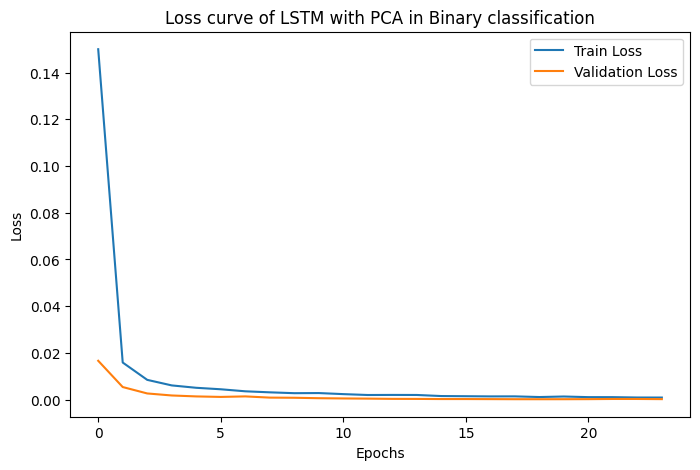

In [ ]:
# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_lstm.history['loss'], label='Train Loss')
plt.plot(his_lstm.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of LSTM with PCA in Binary classification")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **LSTM MODEL EVALUATION AND TESTING**

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 0.84 seconds
AUC score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       1.00      1.00      1.00      4321

    accuracy                           1.00      8706
   macro avg       1.00      1.00      1.00      8706
weighted avg       1.00      1.00      1.00      8706



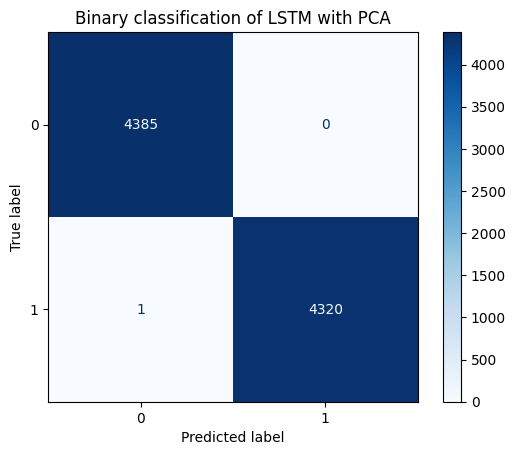

In [ ]:
# ------------------------- Model Testing -------------------------
start_tm = time.time()
y_pred_prob = lstm_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# ------------------------- Prediction Processing -------------------------
y_pred = (y_pred_prob > 0.5).astype(int)

# ------------------------- Model Evaluation -------------------------

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC score: {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# ------------------------ Confusion Matrix -------------------------
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx, display_labels=[0,1])
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Binary classification of LSTM with PCA")
plt.show()

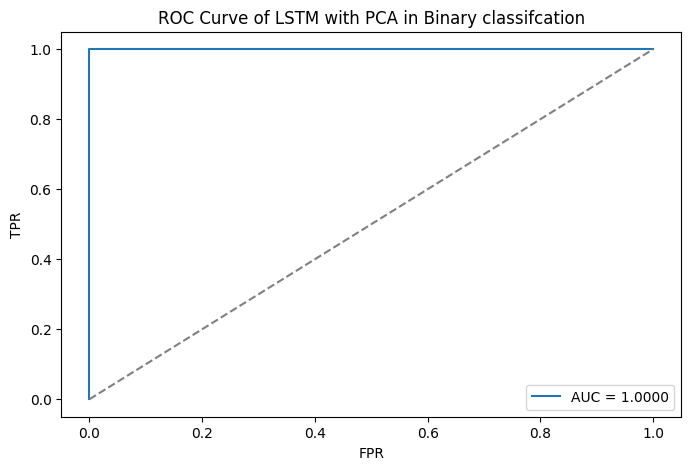

In [ ]:
# ------------------------- ROC Curve -------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve of LSTM with PCA in Binary classifcation")
plt.legend(loc="lower right")
plt.show()

# **RNN MODEL IMPLEMENTATION AND TRAINING**

Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9240 - loss: 0.1852 - val_accuracy: 0.9963 - val_loss: 0.0166
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9966 - loss: 0.0178 - val_accuracy: 0.9974 - val_loss: 0.0078
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9977 - loss: 0.0105 - val_accuracy: 0.9990 - val_loss: 0.0046
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9982 - loss: 0.0076 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 0.0062 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9992 - val_loss: 0.0029
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0025
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.

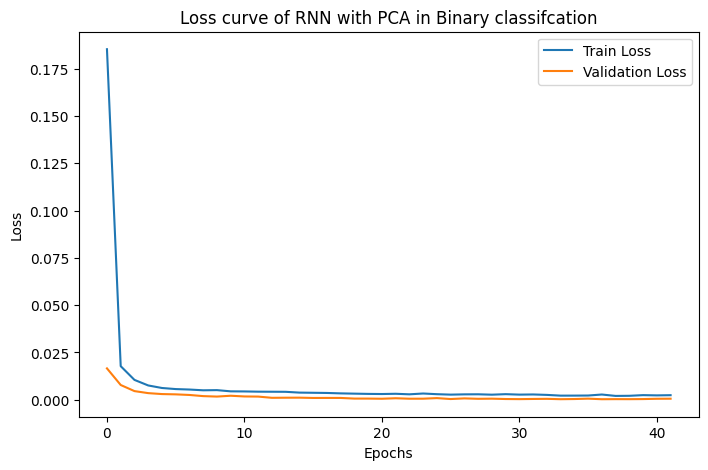

In [ ]:
# ------------------------- RNN Model Architecture -------------------------
rnn_mod = Sequential()
rnn_mod.add(SimpleRNN(32, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
rnn_mod.add(Dropout(0.5))
rnn_mod.add(Dense(1, activation='sigmoid'))

# ------------------------- Model Compilation -------------------------

rnn_mod.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ------------------------- Training Setup -------------------------

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ------------------------- Model Training -------------------------
start_tm = time.time()
his_rnn = rnn_mod.fit(
    X_train_reshap, y_train,
    validation_data=(X_val_reshap, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[stop_overfit],
    verbose=1
)
train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# ------------------------- Training Loss Curve -------------------------

plt.figure(figsize=(8,5))
plt.plot(his_rnn.history['loss'], label='Train Loss')
plt.plot(his_rnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of RNN with PCA in Binary classifcation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **RNN MODEL EVALUATION AND TESTING**

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 1.33 seconds
AUC score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       1.00      1.00      1.00      4321

    accuracy                           1.00      8706
   macro avg       1.00      1.00      1.00      8706
weighted avg       1.00      1.00      1.00      8706



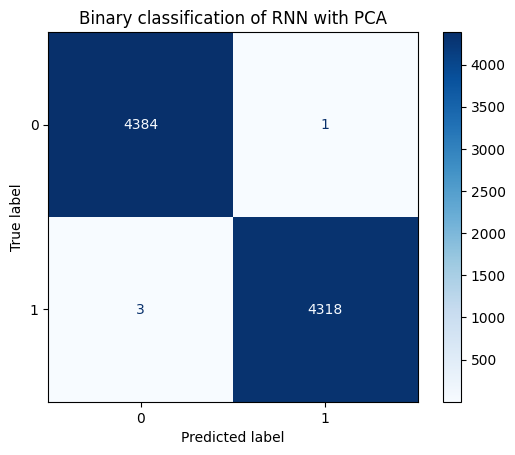

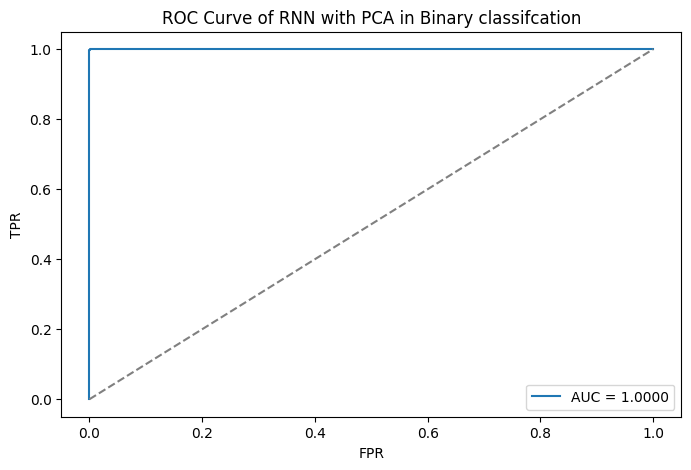

In [ ]:
# ------------------------- Model Testing -------------------------
start_tm = time.time()
y_pred_prob = rnn_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# ------- Convert probabilities to class labels - Prediction Processing -

y_pred = (y_pred_prob > 0.5).astype(int)

# ------------------------- Model Evaluation -------------------------

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC score: {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# ------------------------- Confusion Matrix -------------------------
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx, display_labels=[0,1])
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Binary classification of RNN with PCA")
plt.show()

# ------------------------- ROC Curve -------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve of RNN with PCA in Binary classifcation")
plt.legend(loc="lower right")
plt.show()

# **CNN MODEL IMPLEMENTATION**

**Reshaping the data for CNN - Input shape: [samples, timesteps, channels]**

In [ ]:
# ------------------------- Data Reshaping for CNN -------------------------
X_train_cnn = X_train_pca.reshape((X_train_pca.shape[0], X_train_pca.shape[1], 1))
X_val_cnn   = X_val_pca.reshape((X_val_pca.shape[0], X_val_pca.shape[1], 1))
X_test_cnn  = X_test_pca.reshape((X_test_pca.shape[0], X_test_pca.shape[1], 1))

print("Reshaped training data for CNN:", X_train_cnn.shape)
print("Reshaped validation data for CNN:", X_val_cnn.shape)
print("Reshaped testing data for CNN:", X_test_cnn.shape)

Reshaped training data for CNN: (40625, 10, 1)
Reshaped validation data for CNN: (8706, 10, 1)
Reshaped testing data for CNN: (8706, 10, 1)


Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9715 - loss: 0.1089 - val_accuracy: 0.9967 - val_loss: 0.0127
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9912 - loss: 0.0400 - val_accuracy: 0.9971 - val_loss: 0.0064
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9928 - loss: 0.0306 - val_accuracy: 0.9978 - val_loss: 0.0049
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9927 - loss: 0.0259 - val_accuracy: 0.9997 - val_loss: 0.0046
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9945 - loss: 0.0237 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9940 - loss: 0.0225 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9938 - loss: 0.0250 - val_accuracy: 0.9997 - val_loss: 0.0041
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9941 - loss: 0.0213 - val_accuracy: 0.

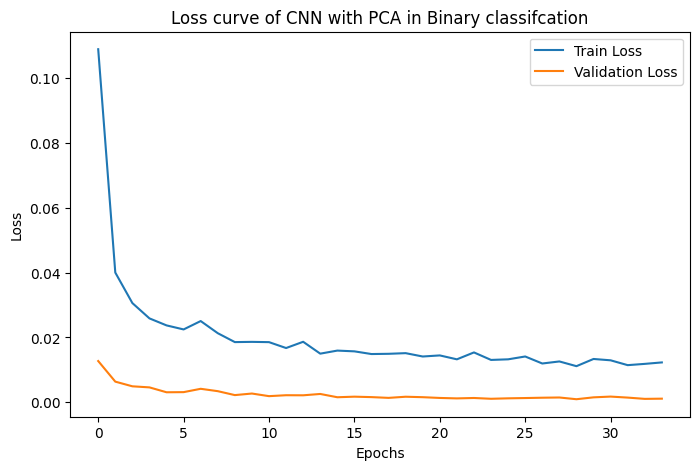

In [ ]:
# ------------------------- CNN Model Architecture -------------------------
cnn_mod = Sequential()
cnn_mod.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
cnn_mod.add(Dropout(0.5))
cnn_mod.add(Flatten())
cnn_mod.add(Dense(16, activation='relu'))
cnn_mod.add(Dropout(0.5))
cnn_mod.add(Dense(1, activation='sigmoid'))

# ------------------------- Model Compilation -------------------------

cnn_mod.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ------------------------- Training Setup -------------------------

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ------------------------- Model Training -------------------------

start_tm = time.time()
his_cnn = cnn_mod.fit(
    X_train_cnn, y_train.to_numpy(),
    validation_data=(X_val_cnn, y_val.to_numpy()),
    epochs=50,
    batch_size=64,
    callbacks=[stop_overfit],
    verbose=1
)
train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# ------------------------- Training Loss Curve -------------------------
plt.figure(figsize=(8,5))
plt.plot(his_cnn.history['loss'], label='Train Loss')
plt.plot(his_cnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of CNN with PCA in Binary classifcation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **CNN MODEL EVALUATION AND TESTING**

273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing time: 0.63 seconds
AUC score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       1.00      1.00      1.00      4321

    accuracy                           1.00      8706
   macro avg       1.00      1.00      1.00      8706
weighted avg       1.00      1.00      1.00      8706



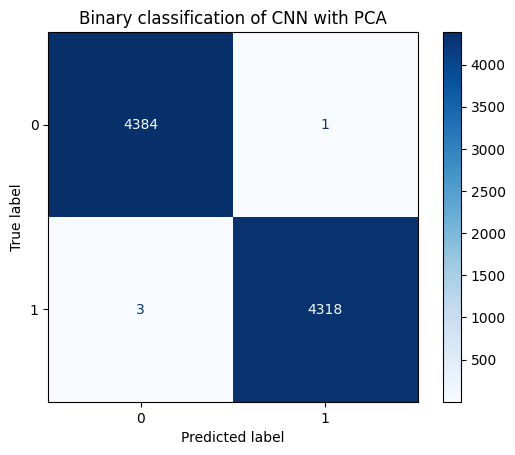

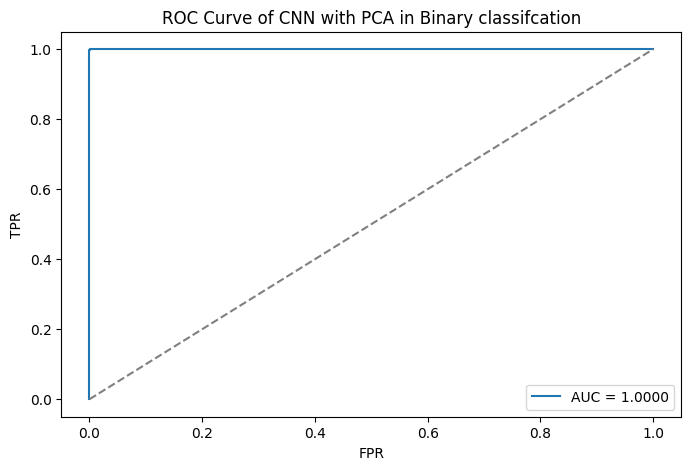

In [ ]:
# ------------------------- Model Testing -------------------------
start_tm = time.time()
y_pred_prob = cnn_mod.predict(X_test_cnn)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to class labels - Prediction Processing -
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_test_np = y_test.to_numpy().flatten()

# ------------------------- Model Evaluation -------------------------

auc_score = roc_auc_score(y_test_np, y_pred_prob)
print(f"AUC score: {auc_score:.4f}")
print(classification_report(y_test_np, y_pred))

# ------------------------- Confusion Matrix -------------------------

c_mtx = confusion_matrix(y_test_np, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx, display_labels=[0,1])
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Binary classification of CNN with PCA")
plt.show()

# ------------------------- ROC Curve -------------------------

fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve of CNN with PCA in Binary classifcation")
plt.legend(loc="lower right")
plt.show()

Binary CICMalMem detection is trivially separable with no dimensional or model pressure remaining. Hence, to introduce meaningful analytical depth, the study is extended to multiclass classification.

# **Multiclass - Classification**

Taking Category as the target variable - Multiclass classification

In [ ]:
mal_mem['Category'].value_counts()

,count
Category,
0,29231
2,9803
1,9523
3,9480


The dataset is imbalanced


# *Data splitting*

In [ ]:
X_feat = mal_mem.drop(columns=['Category'])
y_output = mal_mem['Category']

Splitting: 70% for training, 15% for validation and 15% for testing


In [ ]:
X_train, X_temp, y_train, y_temp = data_split(X_feat, y_output, test_size=0.30, stratify=y_output, random_state=42)
X_val, X_test, y_val, y_test = data_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Training data: {X_train.shape}")
print(f"Validation data: {X_val.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (40625, 53)
Validation data: (8706, 53)
Testing data: (8706, 53)


In [ ]:
print("\nPreview of first five rows of Training data after splitting")
X_train[:5]


Preview of first five rows of Training data after splitting


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,handles.nevent,...,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
8763,43,12,12.476999,281.944157,2170,50.465116,12123,281.944157,1064,4261,...,395,222,26,27,118,122,88,0,8,0
43775,32,13,10.562500,183.656250,1170,36.562500,5877,183.656250,549,1856,...,385,220,26,23,114,115,88,0,8,1
24065,41,14,12.824162,288.906404,2050,50.000000,11845,288.906404,1049,4135,...,395,222,26,27,118,123,88,0,8,0
54142,45,18,9.266667,198.666667,1717,38.155556,8940,198.666667,670,3077,...,389,221,26,24,116,122,87,0,8,1
23479,41,13,13.025191,294.212300,2080,50.271975,12175,294.212300,1066,4359,...,395,222,26,27,118,123,88,0,8,0


# *Data Scaling*

In [ ]:
std_scale = StandardScaler()
X_train_std = std_scale.fit_transform(X_train)
X_val_std = std_scale.transform(X_val)
X_test_std = std_scale.transform(X_test)

print("\nPreview of first three rows of Training data after scaling using standard scaler")
X_train_std[:3]


Preview of first three rows of Training data after scaling using standard scaler


array([[ 0.26611708, -1.0214747 ,  0.71036538,  0.26095026,  1.08062875,
         1.17131129,  0.32673727,  0.18514266,  0.03921924,  0.84683675,
         0.46675776,  0.34010014,  0.91658828,  0.45640657,  0.79100372,
         1.03705945,  0.85403712,  0.90175106,  1.33186562,  1.20576656,
         1.33184893,  0.63910891,  0.23750625,  0.63869969, -0.13282699,
        -0.16421659, -0.13522328, -0.18019181, -0.62857091, -0.04551897,
        -0.48171987, -0.62460999, -0.48231128, -0.62849078, -0.46729126,
        -0.51296532, -0.06083088, -0.54126036, -0.50776665, -0.62189348,
        -0.55388369, -0.61975169,  0.19916653,  0.82501075,  0.30916058,
         0.02487553,  1.26037633,  0.73803555, -0.00763014,  0.34433141,
        -0.03139404,  0.00992327, -0.99271576],
       [-1.60092226, -0.64538797, -0.49534902, -0.49197915, -1.95201864,
        -1.25140305, -0.78180881, -0.38455154, -0.0871076 , -2.14005161,
        -2.22452848, -2.28261079, -1.60943728, -2.16938426, -2.93861919,
   

# *SMOTE - oversampling*

In [ ]:
print("Distribution of labels before SMOTE application:", y_train.value_counts())

Distribution of labels before SMOTE application: Category
0    20461
2     6862
1     6666
3     6636
Name: count, dtype: int64


In [ ]:
smt_balance = SMOTE(random_state=42)

# Apply only on training data
X_train_smt, y_train_smt = smt_balance.fit_resample(X_train_std, y_train)

print("Distribution of labels after SMOTE application:", pd.Series(y_train_smt).value_counts())

Distribution of labels after SMOTE application: Category
0    20461
2    20461
3    20461
1    20461
Name: count, dtype: int64


The training data is balanced using SMOTE.

# **PCA - Linear Dimentionality Reduction**

In [ ]:
pca_linear = PCA(n_components=10)

X_train_pca = pca_linear.fit_transform(X_train_smt)
X_val_pca = pca_linear.transform(X_val_std)
X_test_pca = pca_linear.transform(X_test_std)

print(f"Training data shape after PCA: {X_train_pca.shape}")
print(f"Validation data shape after PCA: {X_val_pca.shape}")
print(f"Testing data shape after PCA: {X_test_pca.shape}")

Training data shape after PCA: (81844, 10)
Validation data shape after PCA: (8706, 10)
Testing data shape after PCA: (8706, 10)


In [ ]:
print("\nPreview of first five rows of Training data after PCA with n_components=10")
X_train_pca[:5]


Preview of first five rows of Training data after PCA with n_components=10


array([[ 6.03314483, -0.80286965,  0.6583425 , -0.42069057, -0.90364583,
        -1.37570356, -0.11900641,  0.70124194,  0.06176813, -0.01824399],
       [-6.05511447, -4.74542793, -0.15167   , -1.02762868,  0.59174023,
        -1.91630442, -0.36122004,  1.81573587,  0.59117876,  0.15446211],
       [ 3.94099964,  1.3184842 , -1.14327706, -1.38211182, -0.21096653,
        -1.32954613, -0.07899547,  0.19172615, -0.9082962 , -0.12142573],
       [ 0.21403074, -0.92136239, -0.1984196 ,  1.02409285,  0.02314721,
         2.37080315, -0.05395576, -0.5200736 , -0.55318957,  0.08386094],
       [ 5.41776936, -1.34025175, -0.06538821, -0.55634951, -0.46694764,
        -1.36300999, -0.12165489,  0.75882914, -0.24136996, -0.15231374]])

**Reshaping the data for LSTM and RNN models - Input shape: [samples, timesteps, features]**

In [ ]:
X_train_reshap = X_train_pca.reshape(X_train_pca.shape[0], 1, X_train_pca.shape[1])
X_val_reshap   = X_val_pca.reshape(X_val_pca.shape[0], 1, X_val_pca.shape[1])
X_test_reshap  = X_test_pca.reshape(X_test_pca.shape[0], 1, X_test_pca.shape[1])

print("Reshaped training data:", X_train_reshap.shape)
print("Reshaped validation data:", X_val_reshap.shape)
print("Reshaped testing data:", X_test_reshap.shape)

Reshaped training data: (81844, 1, 10)
Reshaped validation data: (8706, 1, 10)
Reshaped testing data: (8706, 1, 10)


# **LSTM Model with PCA for Multiclass Classification**

In [ ]:
# Number of classes
output_class = len(np.unique(y_train_smt))

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5480 - loss: 0.8261 - val_accuracy: 0.7300 - val_loss: 0.5102
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5990 - loss: 0.7563 - val_accuracy: 0.7427 - val_loss: 0.4896
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6183 - loss: 0.7371 - val_accuracy: 0.7538 - val_loss: 0.4801
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6267 - loss: 0.7264 - val_accuracy: 0.7560 - val_loss: 0.4736
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6316 - loss: 0.7187 - val_accuracy: 0.7578 - val_loss: 0.4710
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6367 - loss: 0.7126 - val_accuracy: 0.7588 - val_loss: 0.4667
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6417 - loss: 0.7062 - val_accuracy: 0.7581 - val_loss: 0.4649
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6450 - loss: 0.7020 - 

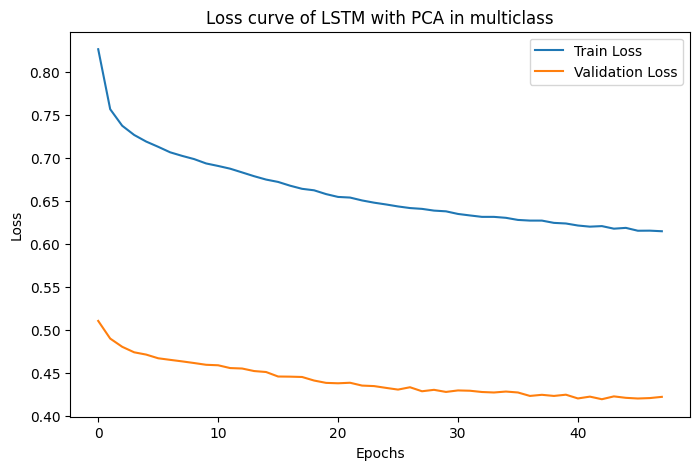

In [ ]:
# ------------------------- Building and Training the LSTM Architecture ---------------------------
lstm_mod = Sequential()
lstm_mod = Sequential()
lstm_mod.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(LSTM(64))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(64, activation='relu'))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(output_class, activation='softmax'))

lstm_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_lstm = lstm_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# ------------------------- Plotting Loss Curve ---------------------------
plt.figure(figsize=(8,5))
plt.plot(his_lstm.history['loss'], label='Train Loss')
plt.plot(his_lstm.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of LSTM with PCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Model Testing and Evaluation**

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.28 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.57      0.53      0.55      1429
           2       0.66      0.63      0.64      1470
           3       0.58      0.65      0.62      1422

    accuracy                           0.80      8706
   macro avg       0.70      0.70      0.70      8706
weighted avg       0.80      0.80      0.80      8706



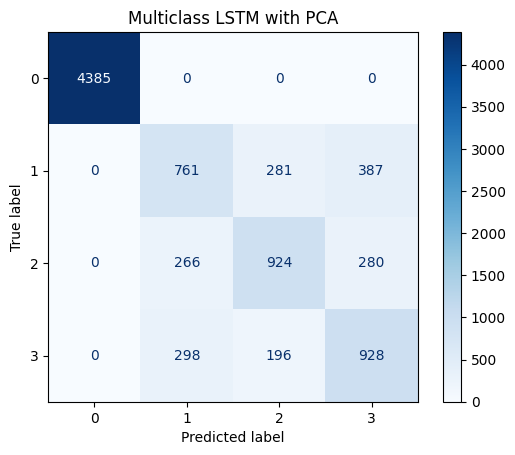

AUC score: 0.9399


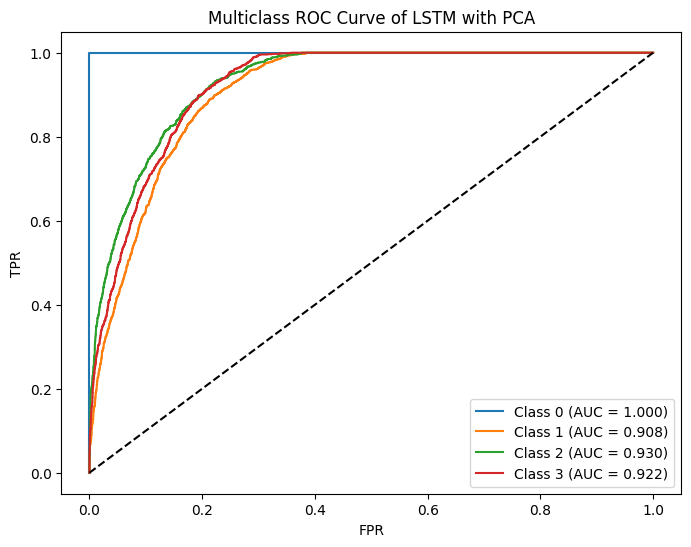

In [ ]:
start_tm = time.time()
y_pred_prob = lstm_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass LSTM with PCA")
plt.show()

# ---------------------- Multiclass AUC Calculation ---------------------
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

# ---------------------- ROC Curve ---------------------
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of LSTM with PCA")
plt.legend()
plt.show()

# **RNN + PCA**

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5755 - loss: 0.7979 - val_accuracy: 0.7317 - val_loss: 0.4958
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6094 - loss: 0.7504 - val_accuracy: 0.7414 - val_loss: 0.4835
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6171 - loss: 0.7402 - val_accuracy: 0.7526 - val_loss: 0.4781
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6214 - loss: 0.7316 - val_accuracy: 0.7547 - val_loss: 0.4731
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6278 - loss: 0.7255 - val_accuracy: 0.7568 - val_loss: 0.4711
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6313 - loss: 0.7202 - val_accuracy: 0.7586 - val_loss: 0.4670
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6368 - loss: 0.7153 - val_accuracy: 0.7595 - val_loss: 0.4663
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6393 - loss: 0.7111 - val_accu

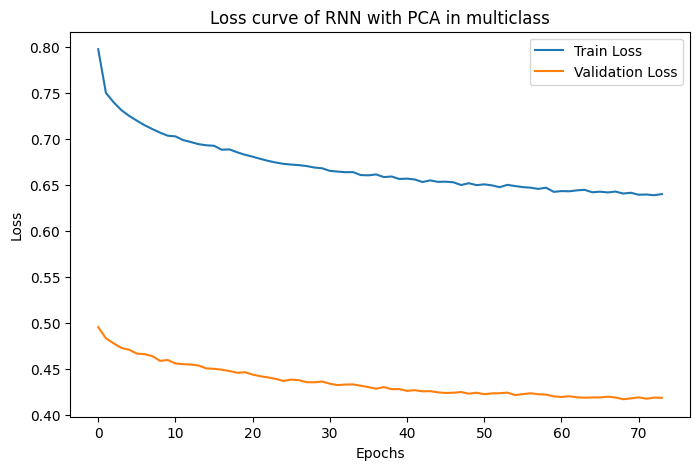

In [ ]:
# ------------------------- Building and Training the RNN Architecture ---------------------------

rnn_mod = Sequential()
rnn_mod.add(SimpleRNN(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(SimpleRNN(64))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(64, activation='relu'))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(output_class, activation='softmax'))

rnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_rnn = rnn_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# ------------------------- Plotting Loss Curve ---------------------------

plt.figure(figsize=(8,5))
plt.plot(his_rnn.history['loss'], label='Train Loss')
plt.plot(his_rnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of RNN with PCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Model Testing and Evaluation**

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 1.05 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.58      0.46      0.52      1429
           2       0.66      0.64      0.65      1470
           3       0.57      0.69      0.62      1422

    accuracy                           0.80      8706
   macro avg       0.70      0.70      0.70      8706
weighted avg       0.80      0.80      0.80      8706



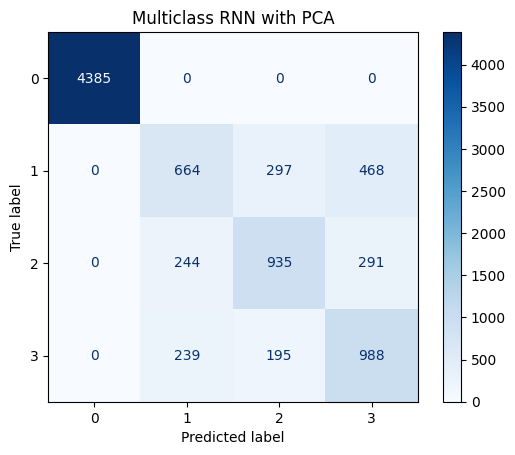

AUC score: 0.9387


In [ ]:
# ----------------------Testing RNN Model ---------------
start_tm = time.time()
y_pred_prob = rnn_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass RNN with PCA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

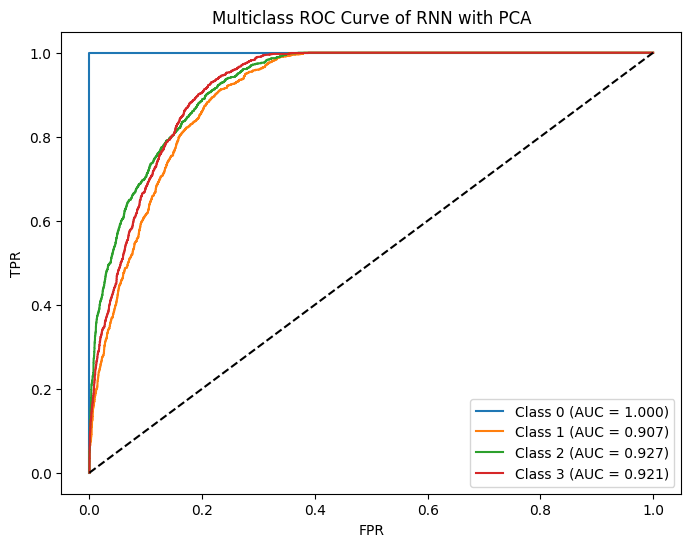

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of RNN with PCA")
plt.legend()
plt.show()

# **CNN + PCA**

**Reshaping the data for CNN - Input shape: [samples, timesteps, channels]**

In [ ]:
X_train_cnn = X_train_pca.reshape((X_train_pca.shape[0], X_train_pca.shape[1], 1))
X_val_cnn   = X_val_pca.reshape((X_val_pca.shape[0], X_val_pca.shape[1], 1))
X_test_cnn  = X_test_pca.reshape((X_test_pca.shape[0], X_test_pca.shape[1], 1))

print("Reshaped training data for CNN:", X_train_cnn.shape)
print("Reshaped validation data for CNN:", X_val_cnn.shape)
print("Reshaped testing data for CNN:", X_test_cnn.shape)

Reshaped training data for CNN: (81844, 10, 1)
Reshaped validation data for CNN: (8706, 10, 1)
Reshaped testing data for CNN: (8706, 10, 1)


Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5815 - loss: 0.7991 - val_accuracy: 0.7419 - val_loss: 0.4981
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6099 - loss: 0.7477 - val_accuracy: 0.7493 - val_loss: 0.4834
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6217 - loss: 0.7321 - val_accuracy: 0.7428 - val_loss: 0.4824
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6310 - loss: 0.7224 - val_accuracy: 0.7590 - val_loss: 0.4722
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6381 - loss: 0.7144 - val_accuracy: 0.7551 - val_loss: 0.4691
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6435 - loss: 0.7067 - val_accuracy: 0.7594 - val_loss: 0.4653
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6471 - loss: 0.7027 - val_accuracy: 0.7638 - val_loss: 0.4631
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6519 - loss: 0.69

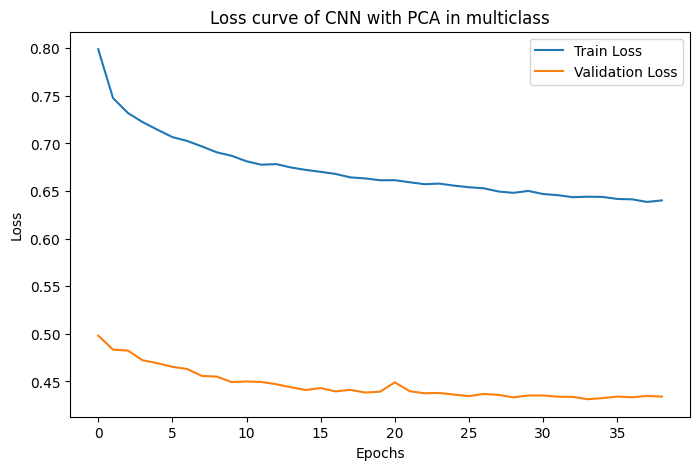

In [ ]:
# ------------------------- Building and Training the 1D CNN Architecture ---------------------------

cnn_mod = Sequential()

# Conv Layer 1
cnn_mod.add(Conv1D(filters=64,
                   kernel_size=3,
                   activation='relu',
                   input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))

# Conv Layer 2
cnn_mod.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))

# Flatten before Dense
cnn_mod.add(Flatten())

# Fully Connected Layer
cnn_mod.add(Dense(64, activation='relu'))
cnn_mod.add(Dropout(0.2))

# Output Layer (Multiclass)
cnn_mod.add(Dense(output_class, activation='softmax'))

cnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_cnn = cnn_mod.fit(
    X_train_cnn, y_train_smt,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss Curve
plt.figure(figsize=(8,5))
plt.plot(his_cnn.history['loss'], label='Train Loss')
plt.plot(his_cnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of CNN with PCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Model Testing and Evaluation**

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.16 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.53      0.52      0.52      1429
           2       0.64      0.60      0.62      1470
           3       0.57      0.60      0.58      1422

    accuracy                           0.79      8706
   macro avg       0.68      0.68      0.68      8706
weighted avg       0.79      0.79      0.79      8706



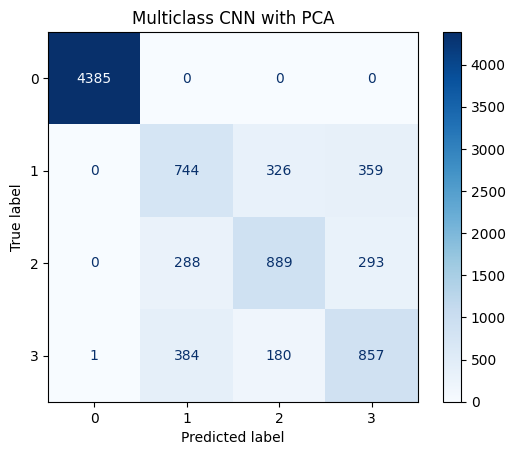

AUC score: 0.9327


In [ ]:
# ----------------------Testing CNN Model ---------------
start_tm = time.time()
y_pred_prob = cnn_mod.predict(X_test_cnn)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass CNN with PCA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

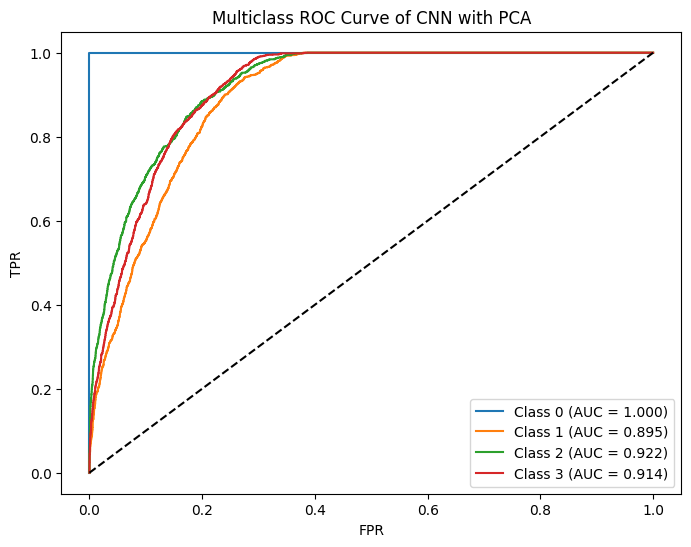

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of CNN with PCA")
plt.legend()
plt.show()

# **LDA - Linear Dimentionality Reduction**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [ ]:
num_of_class = len(np.unique(y_train_smt))
print("Number of classes:", num_of_class)
print("Maximum LDA components allowed:", num_of_class - 1)

Number of classes: 4
Maximum LDA components allowed: 3


In [ ]:
lda_linear = LDA(n_components=3)

X_train_lda = lda_linear.fit_transform(X_train_smt, y_train_smt)
X_val_lda = lda_linear.transform(X_val_std)
X_test_lda = lda_linear.transform(X_test_std)

print(f"Training data shape after LDA: {X_train_lda.shape}")
print(f"Validation data shape after LDA: {X_val_lda.shape}")
print(f"Testing data shape after LDA: {X_test_lda.shape}")

Training data shape after LDA: (81844, 1)
Validation data shape after LDA: (8706, 1)
Testing data shape after LDA: (8706, 1)


In [ ]:
print("Explained variance ratio:", lda_linear.explained_variance_ratio_)
print("Number of components learned:", len(lda_linear.explained_variance_ratio_))

Explained variance ratio: [1.00000000e+00 6.81431509e-28 3.84091894e-28]
Number of components learned: 3


LDA produced three components, but the first captured nearly all class separation, so only one meaningful discriminant is present.

In [ ]:
print("\nPreview of first five rows of Training data after LDA")
X_train_lda[:5]


Preview of first five rows of Training data after LDA


array([[-1.83544630e+13],
       [ 6.11815432e+12],
       [-1.83544630e+13],
       [ 6.11815432e+12],
       [-1.83544630e+13]])

**Reshaping the data for LSTM and RNN models - Input shape: [samples, timesteps, features]**

In [ ]:
X_train_reshap = X_train_lda.reshape((X_train_lda.shape[0], 1, X_train_lda.shape[1]))
X_val_reshap = X_val_lda.reshape((X_val_lda.shape[0], 1, X_val_lda.shape[1]))
X_test_reshap = X_test_lda.reshape((X_test_lda.shape[0], 1, X_test_lda.shape[1]))

print("Reshaped training data:", X_train_reshap.shape)
print("Reshaped validation data:", X_val_reshap.shape)
print("Reshaped testing data:", X_test_reshap.shape)

Reshaped training data: (81844, 1, 1)
Reshaped validation data: (8706, 1, 1)
Reshaped testing data: (8706, 1, 1)


# **LSTM + LDA**

In [ ]:
# Number of classes
output_class = len(np.unique(y_train_smt))

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4990 - loss: 0.8472 - val_accuracy: 0.6670 - val_loss: 0.5455
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5006 - loss: 0.8256 - val_accuracy: 0.6677 - val_loss: 0.5454
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4991 - loss: 0.8249 - val_accuracy: 0.6726 - val_loss: 0.5453
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4988 - loss: 0.8246 - val_accuracy: 0.6670 - val_loss: 0.5453
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5000 - loss: 0.8245 - val_accuracy: 0.6726 - val_loss: 0.5454
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5002 - loss: 0.8244 - val_accuracy: 0.6670 - val_loss: 0.5456
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4999 - loss: 0.8243 - val_accuracy: 0.6726 - val_loss: 0.5453
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5008 - loss: 0.8243 - v

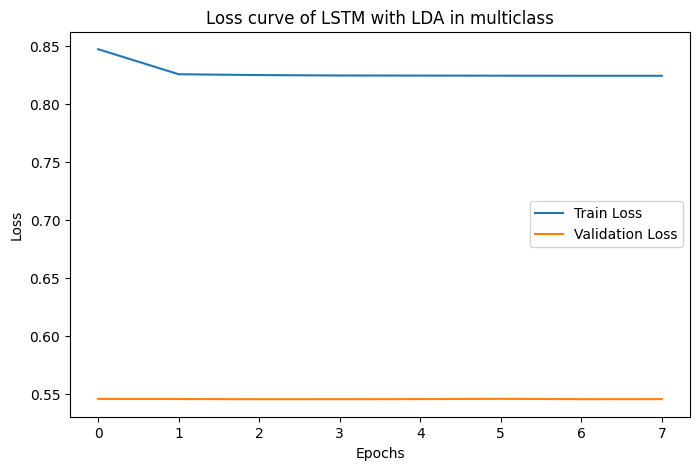

In [ ]:
#------------------------- Building and Training the LSTM Architecture ---------------------------
lstm_mod = Sequential()
lstm_mod.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(LSTM(64))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(64, activation='relu'))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(output_class, activation='softmax'))

lstm_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_lstm = lstm_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_lstm.history['loss'], label='Train Loss')
plt.plot(his_lstm.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of LSTM with LDA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.52 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.00      0.00      0.00      1429
           2       0.34      1.00      0.51      1470
           3       0.00      0.00      0.00      1422

    accuracy                           0.67      8706
   macro avg       0.34      0.50      0.38      8706
weighted avg       0.56      0.67      0.59      8706



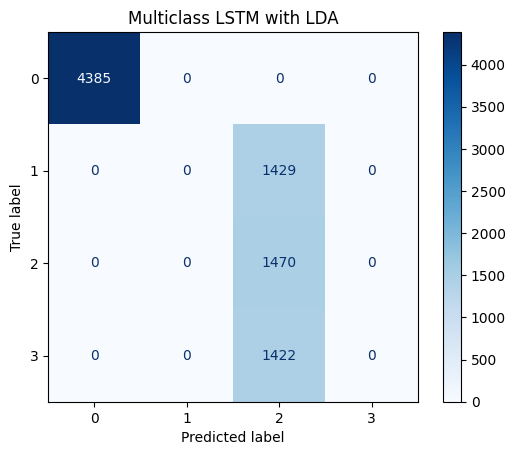

AUC score: 0.8512


In [ ]:
# ----------------------Testing LSTM Model ---------------
start_tm = time.time()
y_pred_prob = lstm_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass LSTM with LDA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

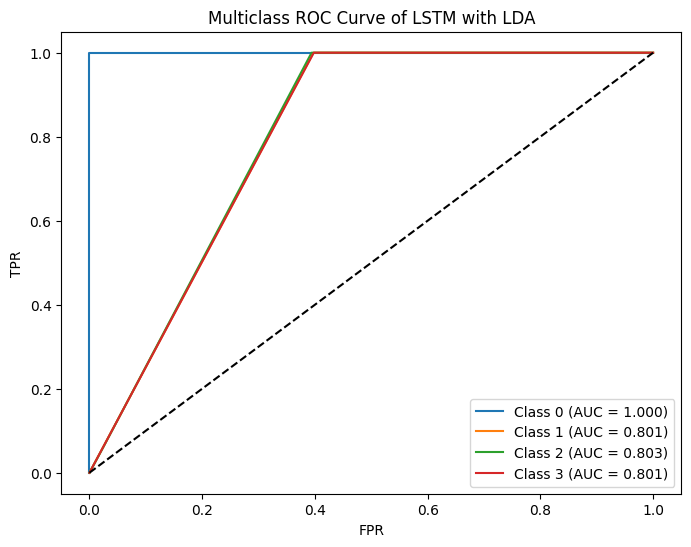

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of LSTM with LDA")
plt.legend()
plt.show()

# **RNN + LDA**

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4987 - loss: 0.8459 - val_accuracy: 0.6677 - val_loss: 0.5463
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4984 - loss: 0.8253 - val_accuracy: 0.6726 - val_loss: 0.5455
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4990 - loss: 0.8249 - val_accuracy: 0.6677 - val_loss: 0.5453
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5010 - loss: 0.8247 - val_accuracy: 0.6726 - val_loss: 0.5453
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5018 - loss: 0.8247 - val_accuracy: 0.6726 - val_loss: 0.5452
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5020 - loss: 0.8244 - val_accuracy: 0.6726 - val_loss: 0.5452
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4999 - loss: 0.8245 - val_accuracy: 0.6670 - val_loss: 0.5459
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5004 - loss: 0.8244 - val_accu

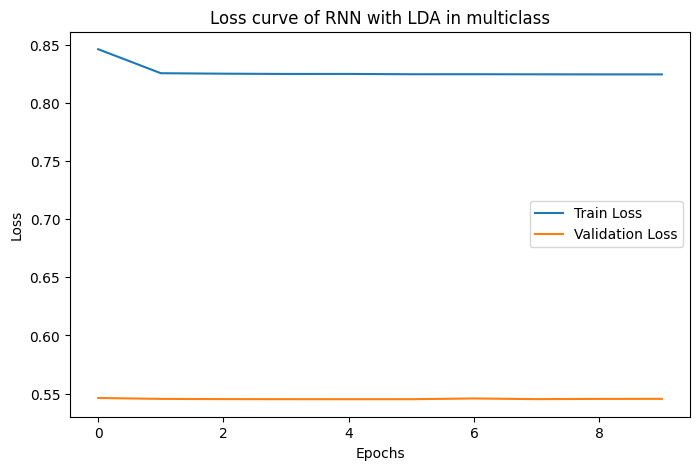

In [ ]:
# ------------------------- Building and Training the RNN Architecture ---------------------------
rnn_mod = Sequential()
rnn_mod.add(SimpleRNN(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(SimpleRNN(64))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(64, activation='relu'))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(output_class, activation='softmax'))

rnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_rnn = rnn_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_rnn.history['loss'], label='Train Loss')
plt.plot(his_rnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of RNN with LDA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 1.04 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.00      0.00      0.00      1429
           2       0.34      1.00      0.51      1470
           3       0.00      0.00      0.00      1422

    accuracy                           0.67      8706
   macro avg       0.34      0.50      0.38      8706
weighted avg       0.56      0.67      0.59      8706



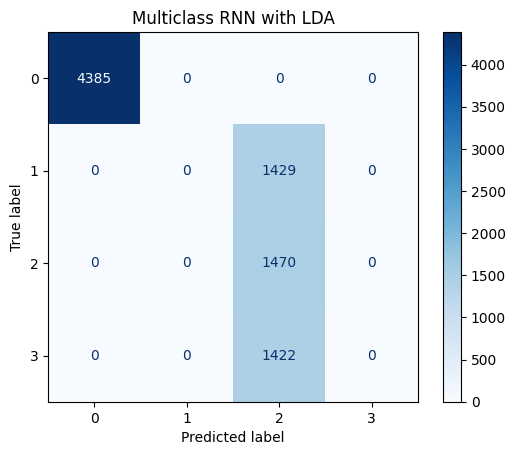

AUC score: 0.8511


In [ ]:
# ----------------------Testing RNN Model ---------------
start_tm = time.time()
y_pred_prob = rnn_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass RNN with LDA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

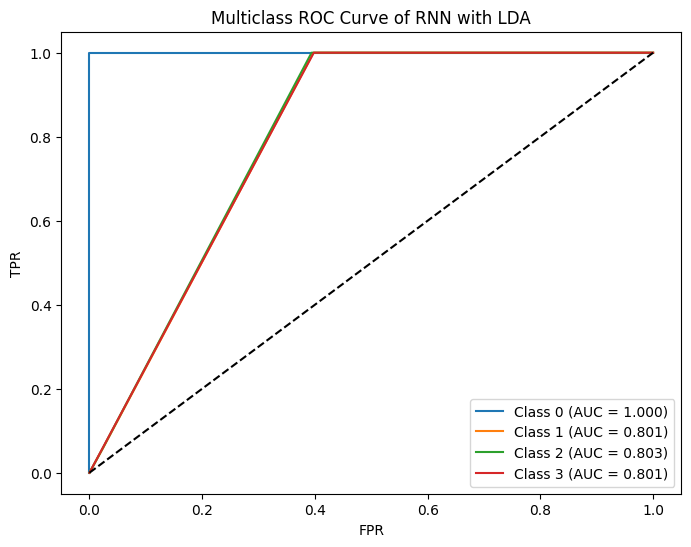

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of RNN with LDA")
plt.legend()
plt.show()

# **CNN + LDA**

**Reshaping the data for CNN - Input shape: [samples, timesteps, channels]**

In [ ]:
X_train_cnn = X_train_lda.reshape((X_train_lda.shape[0], X_train_lda.shape[1], 1))
X_val_cnn   = X_val_lda.reshape((X_val_lda.shape[0], X_val_lda.shape[1], 1))
X_test_cnn  = X_test_lda.reshape((X_test_lda.shape[0], X_test_lda.shape[1], 1))

print("Reshaped training data for CNN:", X_train_cnn.shape)
print("Reshaped validation data for CNN:", X_val_cnn.shape)
print("Reshaped testing data for CNN:", X_test_cnn.shape)

Reshaped training data for CNN: (81844, 1, 1)
Reshaped validation data for CNN: (8706, 1, 1)
Reshaped testing data for CNN: (8706, 1, 1)


Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4987 - loss: 15130303488.0000 - val_accuracy: 0.6677 - val_loss: 1512085.2500
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4998 - loss: 61464716.0000 - val_accuracy: 0.6670 - val_loss: 0.5825
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5007 - loss: 24692358.0000 - val_accuracy: 0.6677 - val_loss: 0.5664
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4995 - loss: 12799301.0000 - val_accuracy: 0.6677 - val_loss: 0.5586
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4995 - loss: 5048949.5000 - val_accuracy: 0.6677 - val_loss: 0.5542
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5005 - loss: 3710278.5000 - val_accuracy: 0.6726 - val_loss: 0.5515
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4996 - loss: 2877539.7500 - val_accuracy: 0.6677 - val_loss: 0.5499
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4

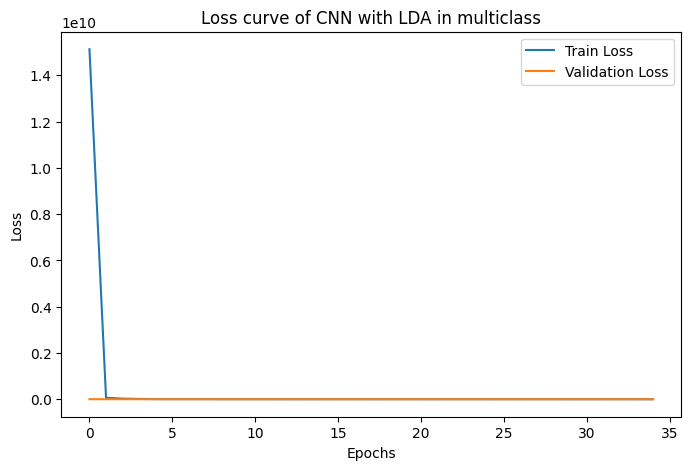

In [ ]:
# ------------------------- Building and Training the 1D CNN Architecture ---------------------------

cnn_mod = Sequential()

cnn_mod.add(Conv1D(filters=64,
                   kernel_size=1,
                   activation='relu',
                   input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))

cnn_mod.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))
cnn_mod.add(Flatten())
cnn_mod.add(Dense(64, activation='relu'))
cnn_mod.add(Dropout(0.2))

# Output Layer
cnn_mod.add(Dense(output_class, activation='softmax'))

cnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_cnn = cnn_mod.fit(
    X_train_cnn, y_train_smt,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss Curve
plt.figure(figsize=(8,5))
plt.plot(his_cnn.history['loss'], label='Train Loss')
plt.plot(his_cnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of CNN with LDA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 0.69 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.00      0.00      0.00      1429
           2       0.34      1.00      0.51      1470
           3       0.00      0.00      0.00      1422

    accuracy                           0.67      8706
   macro avg       0.34      0.50      0.38      8706
weighted avg       0.56      0.67      0.59      8706



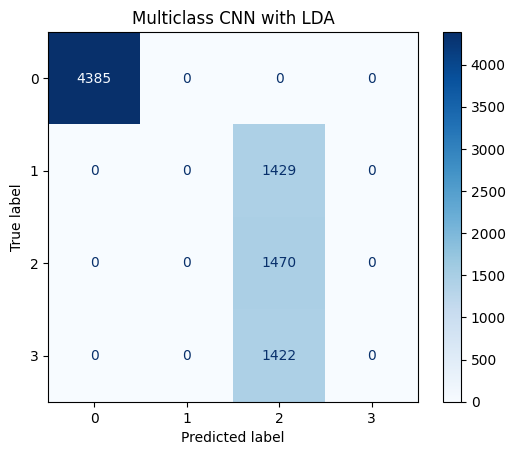

AUC score: 0.8513


In [ ]:
# ----------------------Testing CNN Model ---------------
start_tm = time.time()
y_pred_prob = cnn_mod.predict(X_test_cnn)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass CNN with LDA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

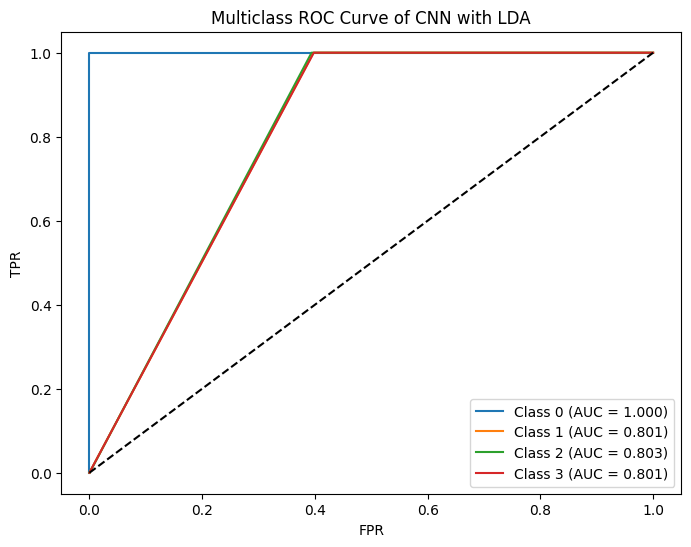

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of CNN with LDA")
plt.legend()
plt.show()

# **Kernel PCA - Non-linear Dimentionality Reduction**

Run time crashed with full dataset so reduced the training set for kernel pca

In [ ]:
from sklearn.decomposition import KernelPCA

# Reduce training data to avoid memory crash (stratified)
X_train_sub, _, y_train_sub, _ = data_split(X_train_smt, y_train_smt, train_size=0.3, stratify=y_train_smt, random_state=42)

kpca_nonlinear = KernelPCA(n_components=10, kernel='sigmoid', gamma=0.1, coef0=1, random_state=42)
X_train_kpca = kpca_nonlinear.fit_transform(X_train_sub)
X_val_kpca = kpca_nonlinear.transform(X_val_std)
X_test_kpca = kpca_nonlinear.transform(X_test_std)

print(f"Training shape after Kernel PCA: {X_train_kpca.shape}")
print(f"Validation shape after Kernel PCA: {X_val_kpca.shape}")
print(f"Testing shape after Kernel PCA: {X_test_kpca.shape}")

Training shape after Kernel PCA: (24553, 10)
Validation shape after Kernel PCA: (8706, 10)
Testing shape after Kernel PCA: (8706, 10)


In [ ]:
print("\nPreview of first five rows of Training data after KernelPCA with n_components=10")
X_train_kpca[:5]


Preview of first five rows of Training data after KernelPCA with n_components=10


array([[ 1.08105934, -0.43845731, -0.29565112, -0.16225897,  0.07054886,
         0.01716261, -0.01042813, -0.09957618, -0.04120748,  0.10189072],
       [-0.30463614, -0.38476285,  0.15647604, -0.15233643, -0.1417893 ,
        -0.0831549 ,  0.0837504 , -0.14509499,  0.15204232, -0.01281406],
       [ 0.94179855, -0.4704443 , -0.43851965,  0.01716601,  0.21850662,
         0.11340151, -0.13661471, -0.0897855 ,  0.06913897,  0.16934884],
       [-0.57998799,  0.43275515, -0.07369996,  0.11149263, -0.09498617,
         0.06710601,  0.16343079, -0.00764454, -0.03002644, -0.075937  ],
       [-0.29547977, -0.38038431,  0.1525026 , -0.08334813, -0.09369527,
        -0.11042411,  0.09438056, -0.13793583,  0.16440416, -0.00768743]])

**Reshaping the data for LSTM and RNN models - Input shape: [samples, timesteps, features]**

In [ ]:
X_train_reshap = X_train_kpca.reshape(X_train_kpca.shape[0], 1, X_train_kpca.shape[1])
X_val_reshap   = X_val_kpca.reshape(X_val_kpca.shape[0], 1, X_val_kpca.shape[1])
X_test_reshap  = X_test_kpca.reshape(X_test_kpca.shape[0], 1, X_test_kpca.shape[1])

print("Reshaped training data:", X_train_reshap.shape)
print("Reshaped validation data:", X_val_reshap.shape)
print("Reshaped testing data:", X_test_reshap.shape)

Reshaped training data: (24553, 1, 10)
Reshaped validation data: (8706, 1, 10)
Reshaped testing data: (8706, 1, 10)


# **LSTM + KPCA**

In [ ]:
# Number of classes
output_class = len(np.unique(y_train_smt))

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4992 - loss: 0.9658 - val_accuracy: 0.6776 - val_loss: 0.5574
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5188 - loss: 0.8317 - val_accuracy: 0.6927 - val_loss: 0.5469
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5459 - loss: 0.8129 - val_accuracy: 0.7027 - val_loss: 0.5356
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5615 - loss: 0.8022 - val_accuracy: 0.7134 - val_loss: 0.5299
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5725 - loss: 0.7926 - val_accuracy: 0.7205 - val_loss: 0.5236
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5829 - loss: 0.7851 - val_accuracy: 0.7224 - val_loss: 0.5188
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5906 - loss: 0.7784 - val_accuracy: 0.7234 - val_loss: 0.5160
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5974 - loss: 0.7740 - 

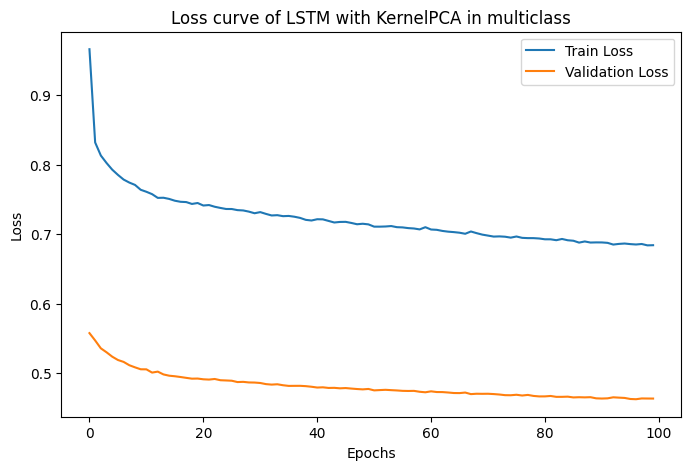

In [ ]:
#------------------------- Building and Training the LSTM Architecture ---------------------------
lstm_mod = Sequential()
lstm_mod.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(LSTM(64))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(64, activation='relu'))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(output_class, activation='softmax'))

lstm_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_lstm = lstm_mod.fit(
    X_train_reshap, y_train_sub,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_lstm.history['loss'], label='Train Loss')
plt.plot(his_lstm.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of LSTM with KernelPCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.36 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.53      0.44      0.48      1429
           2       0.63      0.57      0.60      1470
           3       0.51      0.64      0.57      1422

    accuracy                           0.78      8706
   macro avg       0.67      0.66      0.66      8706
weighted avg       0.78      0.78      0.78      8706



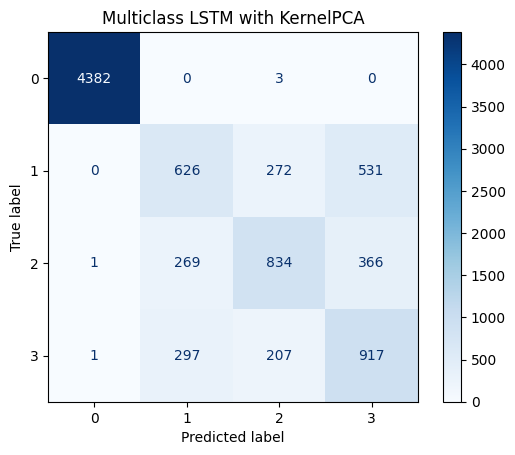

AUC score: 0.9229


In [ ]:
# ----------------------Testing LSTM Model ---------------
start_tm = time.time()
y_pred_prob = lstm_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass LSTM with KernelPCA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

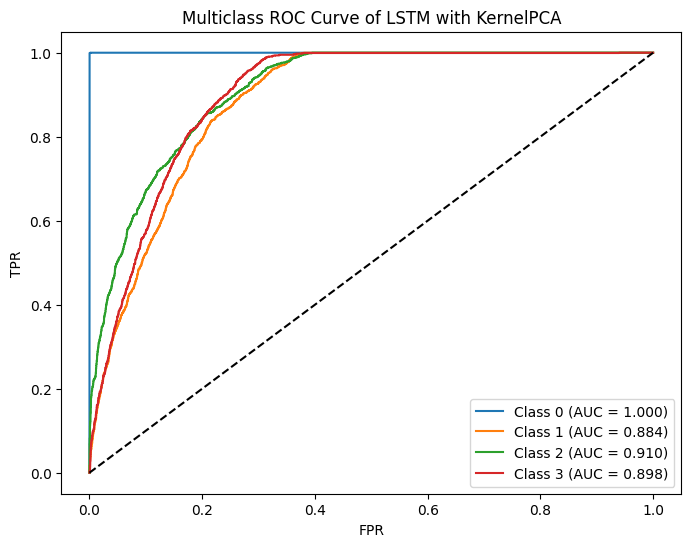

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of LSTM with KernelPCA")
plt.legend()
plt.show()

# **RNN+ KPCA**

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5371 - loss: 0.8709 - val_accuracy: 0.7119 - val_loss: 0.5390
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5739 - loss: 0.8019 - val_accuracy: 0.7220 - val_loss: 0.5249
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5893 - loss: 0.7860 - val_accuracy: 0.7402 - val_loss: 0.5148
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5978 - loss: 0.7744 - val_accuracy: 0.7393 - val_loss: 0.5052
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6069 - loss: 0.7702 - val_accuracy: 0.7470 - val_loss: 0.5075
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6101 - loss: 0.7613 - val_accuracy: 0.7354 - val_loss: 0.5021
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6159 - loss: 0.7600 - val_accuracy: 0.7487 - val_loss: 0.5009
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6101 - loss: 0.7599 - val_a

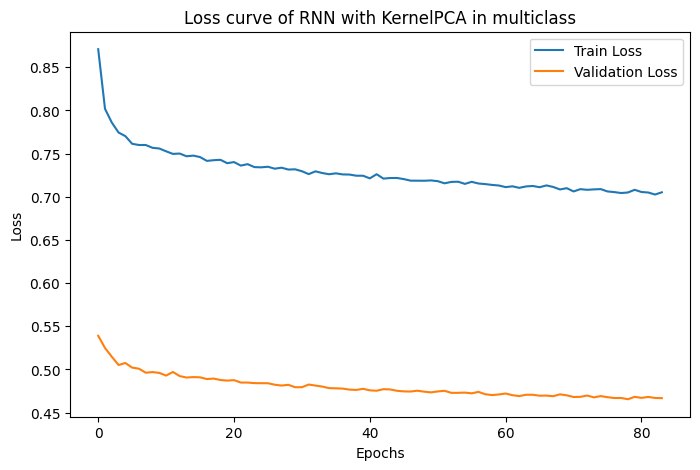

In [ ]:
# ------------------------- Building and Training the RNN Architecture ---------------------------
rnn_mod = Sequential()
rnn_mod.add(SimpleRNN(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(SimpleRNN(64))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(64, activation='relu'))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(output_class, activation='softmax'))

rnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_rnn = rnn_mod.fit(
    X_train_reshap, y_train_sub,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_rnn.history['loss'], label='Train Loss')
plt.plot(his_rnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of RNN with KernelPCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 1.07 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.53      0.36      0.43      1429
           2       0.62      0.54      0.58      1470
           3       0.49      0.71      0.58      1422

    accuracy                           0.77      8706
   macro avg       0.66      0.65      0.65      8706
weighted avg       0.77      0.77      0.77      8706



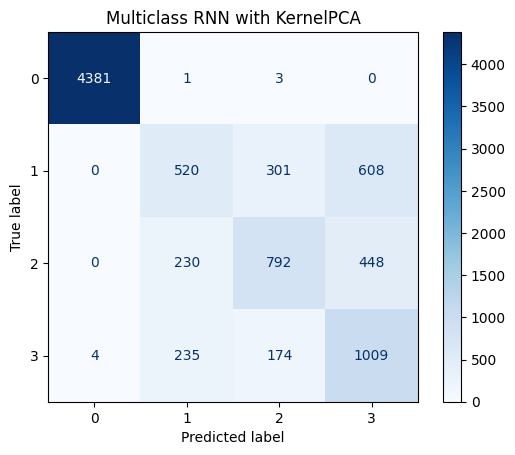

AUC score: 0.9201


In [ ]:
# ----------------------Testing RNN Model ---------------
start_tm = time.time()
y_pred_prob = rnn_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass RNN with KernelPCA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

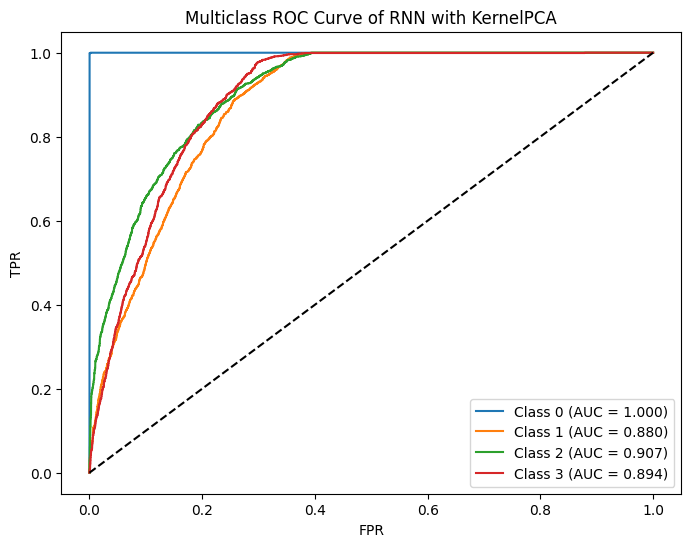

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of RNN with KernelPCA")
plt.legend()
plt.show()

# **CNN+ KPCA**

**Reshaping the data for CNN - Input shape: [samples, timesteps, channels]**

In [ ]:
X_train_cnn = X_train_kpca.reshape((X_train_kpca.shape[0], X_train_kpca.shape[1], 1))
X_val_cnn   = X_val_kpca.reshape((X_val_kpca.shape[0], X_val_kpca.shape[1], 1))
X_test_cnn  = X_test_kpca.reshape((X_test_kpca.shape[0], X_test_kpca.shape[1], 1))

print("Reshaped training data for CNN:", X_train_cnn.shape)
print("Reshaped validation data for CNN:", X_val_cnn.shape)
print("Reshaped testing data for CNN:", X_test_cnn.shape)

Reshaped training data for CNN: (24553, 10, 1)
Reshaped validation data for CNN: (8706, 10, 1)
Reshaped testing data for CNN: (8706, 10, 1)


Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5393 - loss: 0.8796 - val_accuracy: 0.7273 - val_loss: 0.5261
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5877 - loss: 0.7823 - val_accuracy: 0.7351 - val_loss: 0.5146
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6058 - loss: 0.7658 - val_accuracy: 0.7442 - val_loss: 0.5028
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6147 - loss: 0.7570 - val_accuracy: 0.7420 - val_loss: 0.5021
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6236 - loss: 0.7483 - val_accuracy: 0.7517 - val_loss: 0.4934
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6266 - loss: 0.7420 - val_accuracy: 0.7507 - val_loss: 0.4896
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6339 - loss: 0.7360 - val_accuracy: 0.7524 - val_loss: 0.4883
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6354 - loss: 0.7297 - 

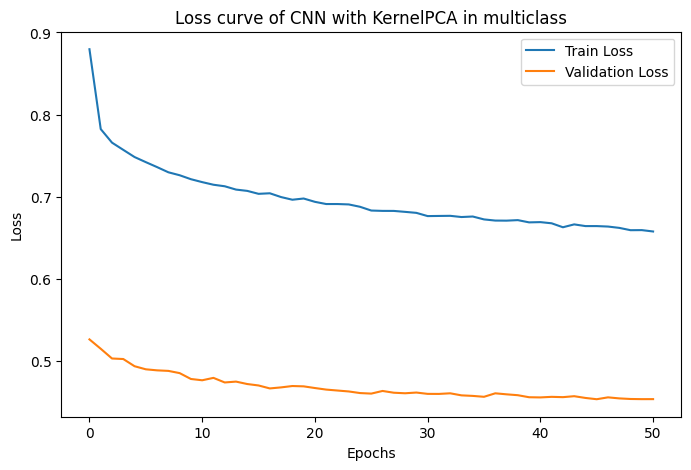

In [ ]:
# ------------------------- Building and Training the 1D CNN Architecture ---------------------------

cnn_mod = Sequential()
cnn_mod.add(Conv1D(filters=64,
                   kernel_size=3,
                   activation='relu',
                   input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))

cnn_mod.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))
cnn_mod.add(Flatten())

cnn_mod.add(Dense(64, activation='relu'))
cnn_mod.add(Dropout(0.2))
cnn_mod.add(Dense(output_class, activation='softmax'))

cnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_cnn = cnn_mod.fit(
    X_train_cnn, y_train_sub,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss Curve
plt.figure(figsize=(8,5))
plt.plot(his_cnn.history['loss'], label='Train Loss')
plt.plot(his_cnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of CNN with KernelPCA in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.20 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.52      0.45      0.48      1429
           2       0.65      0.55      0.59      1470
           3       0.51      0.67      0.58      1422

    accuracy                           0.78      8706
   macro avg       0.67      0.67      0.66      8706
weighted avg       0.78      0.78      0.78      8706



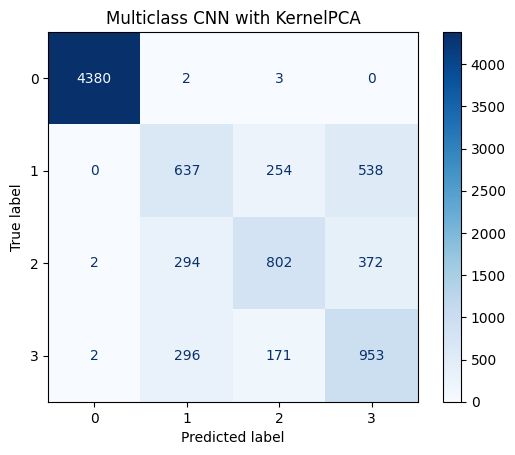

AUC score: 0.9257


In [ ]:
# ----------------------Testing CNN Model ---------------
start_tm = time.time()
y_pred_prob = cnn_mod.predict(X_test_cnn)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass CNN with KernelPCA")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

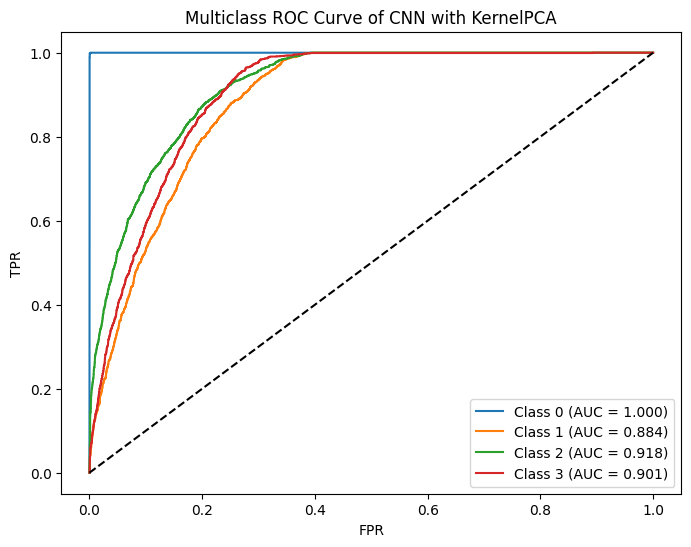

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of CNN with KernelPCA")
plt.legend()
plt.show()

# **Autoencoder-based compression - Non-linear Dimentionality Reduction**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

In [ ]:
input_dim = X_train_smt.shape[1]
latent_dim = 10  # compressed dimension

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile and train
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(
    X_train_smt, X_train_smt,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_std, X_val_std)
)

# Compressed features
X_train_ae = encoder.predict(X_train_smt)
X_val_ae = encoder.predict(X_val_std)
X_test_ae = encoder.predict(X_test_std)

print("Training data shape after AE:", X_train_ae.shape)
print("Validation data shape after AE:", X_val_ae.shape)
print("Testing data shape after AE:", X_test_ae.shape)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4526 - val_loss: 0.1801
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1765 - val_loss: 0.1223
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1092 - val_loss: 0.1363
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0778 - val_loss: 0.0809
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0477 - val_loss: 0.0626
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0378 - val_loss: 0.0514
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0499 - val_loss: 0.0823
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0634 - val_loss: 0.0611
Epoch 9/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0464 - val_loss: 0.0479
Epoch 10/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0293 - val_loss: 0.0428
Epoch 11/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0275 - val_loss: 0.0415
Epoch 12/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [ ]:
print("\nPreview of first five rows of Training data after AE")
X_train_ae[:5]


Preview of first five rows of Training data after AE


array([[0.8933389 , 0.        , 1.4425588 , 3.1842587 , 0.8746466 ,
        1.7914869 , 0.        , 0.39060056, 0.56667906, 1.4654747 ],
       [2.061682  , 7.5005884 , 0.        , 0.4959712 , 1.5383126 ,
        0.0116494 , 3.975993  , 5.783534  , 7.456286  , 4.5873976 ],
       [1.0816447 , 0.0091181 , 1.2734962 , 3.0081635 , 1.5188409 ,
        1.7408346 , 0.        , 0.028192  , 2.2518396 , 2.7908149 ],
       [1.415309  , 2.1464798 , 0.72985077, 0.38292915, 0.8471599 ,
        0.07285016, 0.4590048 , 0.58830154, 1.1330259 , 3.0173647 ],
       [0.73759174, 0.        , 1.0773464 , 2.6791785 , 0.48544836,
        1.82302   , 0.        , 0.17405793, 1.026281  , 1.0714843 ]],
      dtype=float32)

**Reshaping the data for LSTM and RNN models - Input shape: [samples, timesteps, features]**

In [ ]:
X_train_reshap = X_train_ae.reshape(X_train_ae.shape[0], 1, X_train_ae.shape[1])
X_val_reshap   = X_val_ae.reshape(X_val_ae.shape[0], 1, X_val_ae.shape[1])
X_test_reshap  = X_test_ae.reshape(X_test_ae.shape[0], 1, X_test_ae.shape[1])

print("Reshaped training data:", X_train_reshap.shape)
print("Reshaped validation data:", X_val_reshap.shape)
print("Reshaped testing data:", X_test_reshap.shape)

Reshaped training data: (81844, 1, 10)
Reshaped validation data: (8706, 1, 10)
Reshaped testing data: (8706, 1, 10)


# **LSTM + AE**

In [ ]:
# Number of classes
output_class = len(np.unique(y_train_smt))

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5396 - loss: 0.8345 - val_accuracy: 0.7010 - val_loss: 0.5209
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5809 - loss: 0.7736 - val_accuracy: 0.7310 - val_loss: 0.4963
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5987 - loss: 0.7492 - val_accuracy: 0.7336 - val_loss: 0.4852
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6110 - loss: 0.7388 - val_accuracy: 0.7482 - val_loss: 0.4824
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6171 - loss: 0.7304 - val_accuracy: 0.7548 - val_loss: 0.4749
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6213 - loss: 0.7259 - val_accuracy: 0.7597 - val_loss: 0.4718
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6277 - loss: 0.7212 - val_accuracy: 0.7638 - val_loss: 0.4686
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6311 - loss: 0.7157 - 

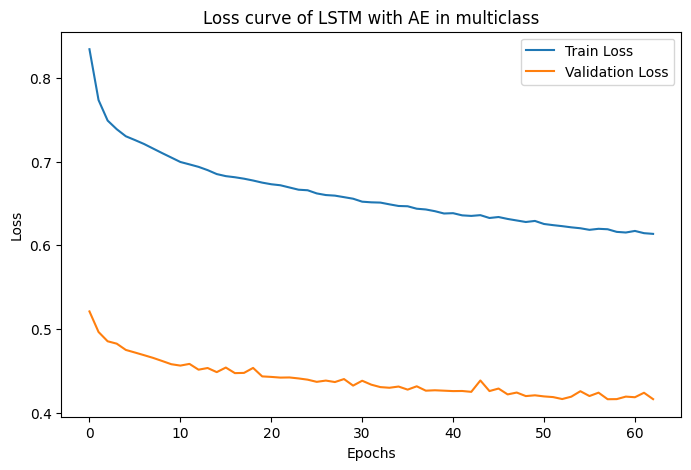

In [ ]:
#------------------------- Building and Training the LSTM Architecture ---------------------------
lstm_mod = Sequential()
lstm_mod.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(LSTM(64))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(64, activation='relu'))
lstm_mod.add(Dropout(0.2))
lstm_mod.add(Dense(output_class, activation='softmax'))

lstm_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_lstm = lstm_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_lstm.history['loss'], label='Train Loss')
plt.plot(his_lstm.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of LSTM with AE in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.37 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.57      0.49      0.53      1429
           2       0.66      0.66      0.66      1470
           3       0.58      0.67      0.62      1422

    accuracy                           0.80      8706
   macro avg       0.70      0.70      0.70      8706
weighted avg       0.80      0.80      0.80      8706



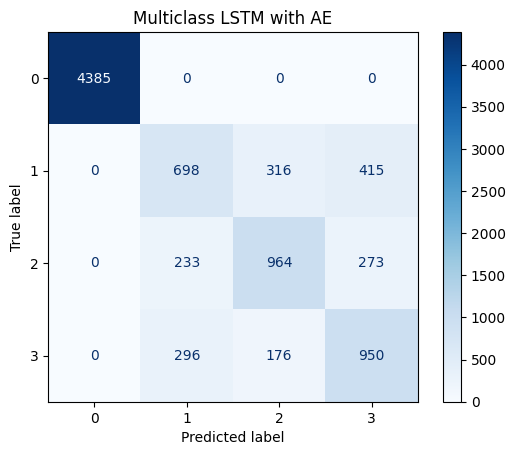

AUC score: 0.9397


In [ ]:
# ----------------------Testing LSTM Model ---------------
start_tm = time.time()
y_pred_prob = lstm_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass LSTM with AE")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

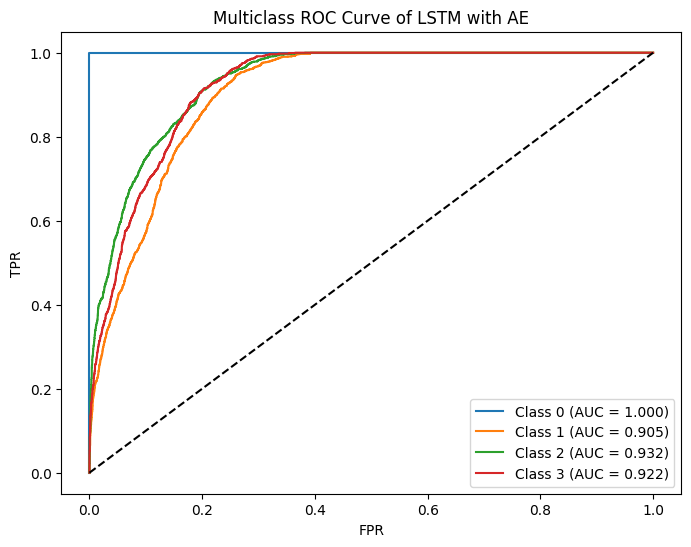

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of LSTM with AE")
plt.legend()
plt.show()

# **RNN + AE**

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5535 - loss: 0.8101 - val_accuracy: 0.7274 - val_loss: 0.5001
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5949 - loss: 0.7582 - val_accuracy: 0.7402 - val_loss: 0.4880
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6066 - loss: 0.7462 - val_accuracy: 0.7434 - val_loss: 0.4821
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6167 - loss: 0.7370 - val_accuracy: 0.7491 - val_loss: 0.4778
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6217 - loss: 0.7314 - val_accuracy: 0.7509 - val_loss: 0.4726
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6239 - loss: 0.7257 - val_accuracy: 0.7568 - val_loss: 0.4690
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6276 - loss: 0.7211 - val_accuracy: 0.7592 - val_loss: 0.4649
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6307 - loss: 0.7182 - val_accu

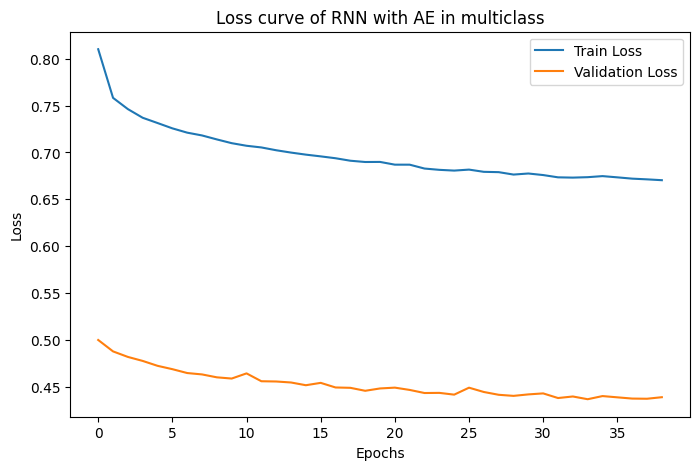

In [ ]:
# ------------------------- Building and Training the RNN Architecture ---------------------------
rnn_mod = Sequential()
rnn_mod.add(SimpleRNN(128, return_sequences=True, input_shape=(X_train_reshap.shape[1], X_train_reshap.shape[2])))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(SimpleRNN(64))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(64, activation='relu'))
rnn_mod.add(Dropout(0.2))
rnn_mod.add(Dense(output_class, activation='softmax'))

rnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_rnn = rnn_mod.fit(
    X_train_reshap, y_train_smt,
    validation_data=(X_val_reshap, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss curve
plt.figure(figsize=(8,5))
plt.plot(his_rnn.history['loss'], label='Train Loss')
plt.plot(his_rnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of RNN with AE in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing time: 1.59 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.53      0.42      0.47      1429
           2       0.65      0.56      0.61      1470
           3       0.52      0.70      0.60      1422

    accuracy                           0.78      8706
   macro avg       0.68      0.67      0.67      8706
weighted avg       0.79      0.78      0.78      8706



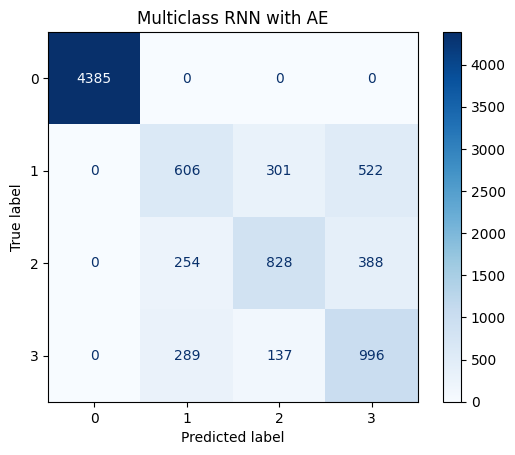

AUC score: 0.9301


In [ ]:
# ----------------------Testing RNN Model ---------------
start_tm = time.time()
y_pred_prob = rnn_mod.predict(X_test_reshap)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass RNN with AE")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

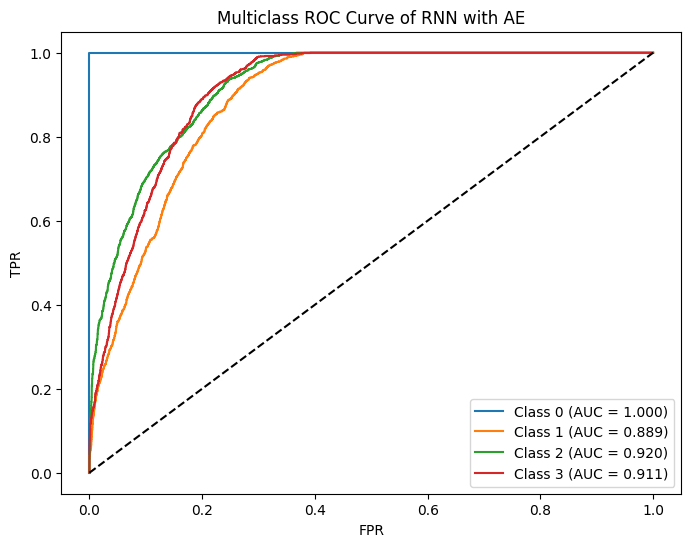

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of RNN with AE")
plt.legend()
plt.show()

# **CNN + AE**

**Reshaping the data for CNN - Input shape: [samples, timesteps, channels]**

In [ ]:
X_train_cnn = X_train_ae.reshape((X_train_ae.shape[0], X_train_ae.shape[1], 1))
X_val_cnn   = X_val_ae.reshape((X_val_ae.shape[0], X_val_ae.shape[1], 1))
X_test_cnn  = X_test_ae.reshape((X_test_ae.shape[0], X_test_ae.shape[1], 1))

print("Reshaped training data for CNN:", X_train_cnn.shape)
print("Reshaped validation data for CNN:", X_val_cnn.shape)
print("Reshaped testing data for CNN:", X_test_cnn.shape)

Reshaped training data for CNN: (81844, 10, 1)
Reshaped validation data for CNN: (8706, 10, 1)
Reshaped testing data for CNN: (8706, 10, 1)


Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5590 - loss: 0.8193 - val_accuracy: 0.7434 - val_loss: 0.4982
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6038 - loss: 0.7519 - val_accuracy: 0.7516 - val_loss: 0.4851
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6145 - loss: 0.7400 - val_accuracy: 0.7493 - val_loss: 0.4811
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6189 - loss: 0.7340 - val_accuracy: 0.7563 - val_loss: 0.4792
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6232 - loss: 0.7307 - val_accuracy: 0.7516 - val_loss: 0.4754
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6273 - loss: 0.7243 - val_accuracy: 0.7595 - val_loss: 0.4732
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6304 - loss: 0.7196 - val_accuracy: 0.7659 - val_loss: 0.4678
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6357 - loss: 0.71

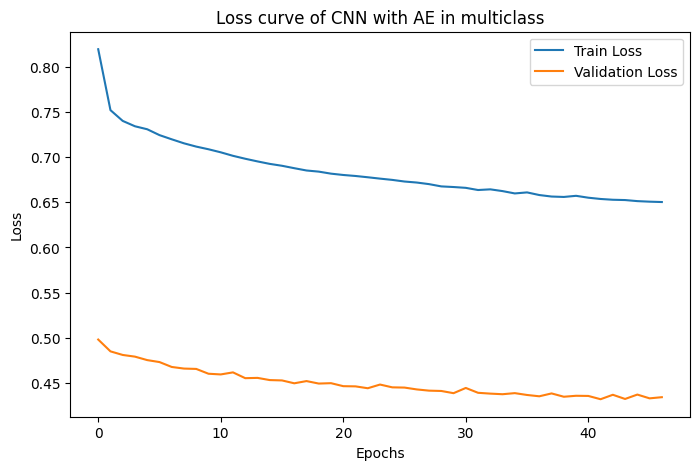

In [ ]:
# ------------------------- Building and Training the 1D CNN Architecture ---------------------------

cnn_mod = Sequential()
cnn_mod.add(Conv1D(filters=64,
                   kernel_size=3,
                   activation='relu',
                   input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))

cnn_mod.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_mod.add(MaxPooling1D(pool_size=1))
cnn_mod.add(Dropout(0.2))
cnn_mod.add(Flatten())
cnn_mod.add(Dense(64, activation='relu'))
cnn_mod.add(Dropout(0.2))

cnn_mod.add(Dense(output_class, activation='softmax'))

cnn_mod.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

stop_overfit = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_tm = time.time()
his_cnn = cnn_mod.fit(
    X_train_cnn, y_train_smt,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[stop_overfit],
    verbose=1
)

train_tm = time.time() - start_tm
print(f"\nTraining time: {train_tm:.2f} seconds")

# Plotting Loss Curve
plt.figure(figsize=(8,5))
plt.plot(his_cnn.history['loss'], label='Train Loss')
plt.plot(his_cnn.history['val_loss'], label='Validation Loss')
plt.title("Loss curve of CNN with AE in multiclass")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Testing time: 0.90 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4385
           1       0.54      0.48      0.51      1429
           2       0.63      0.60      0.61      1470
           3       0.56      0.65      0.60      1422

    accuracy                           0.79      8706
   macro avg       0.68      0.68      0.68      8706
weighted avg       0.79      0.79      0.79      8706



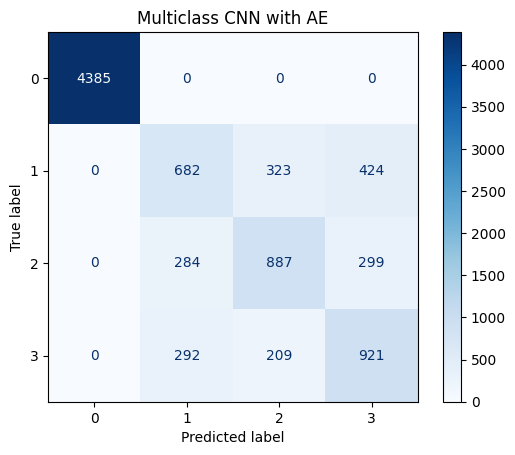

AUC score: 0.9337


In [ ]:
# ----------------------Testing CNN Model ---------------
start_tm = time.time()
y_pred_prob = cnn_mod.predict(X_test_cnn)
test_tm = time.time() - start_tm
print(f"Testing time: {test_tm:.2f} seconds")

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

# Confusion Matrix
c_mtx = confusion_matrix(y_test, y_pred)
c_dsp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
c_dsp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass CNN with AE")
plt.show()

# Multiclass AUC (One-vs-Rest)
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
print(f"AUC score: {auc_score:.4f}")

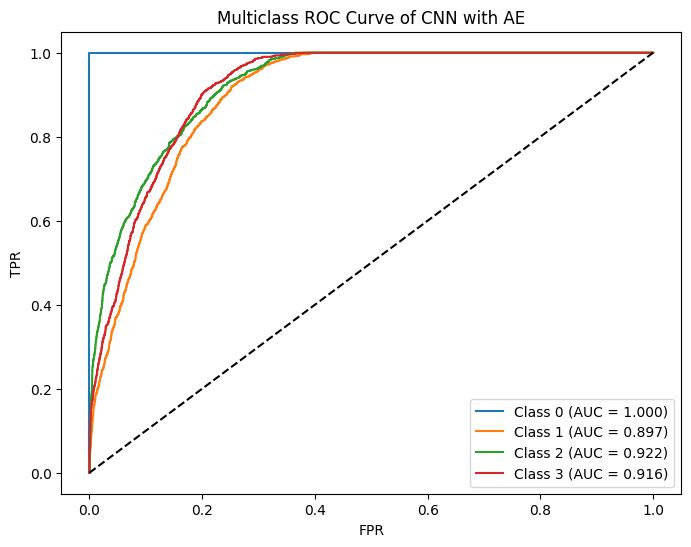

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve of CNN with AE")
plt.legend()
plt.show()